In [1]:
import numpy as np
import math
import time
from datetime import datetime
import os
import shutil # for copying checkpoint to "last"
from pathlib import Path
import gc

import torch
import torch.nn as nn
import torchvision.transforms as transform

from torch.utils.tensorboard import SummaryWriter
import matplotlib.pylab as plt
%matplotlib inline
from IPython.display import Audio

from utils.utils import param_breakdown

from audioDataLoader.audio_dataset import LatentDatasetConfig, EnCodecLatentDataset, latents_to_audio_simple, efficient_codes_to_latents
from torch.utils.data import DataLoader

import model.gru_audio_model

from transformers import EncodecModel

/home/lonce/miniconda3/envs/basicaudio/lib/python3.12/site-packages/requests/__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


In [2]:
# The syn7wav24_tokens_HFdataset_5 has the following parameters: 
#         ['Full File Name', 'class_name', 'param1', 'param2', 'param3', 'param0', 'audio']
# and the following unique 'class_name' values:
#         Class list: ['ChirpPattern', 'DSApplause', 'DSBugs', 'DSPeepers', 'DSPistons', 'DSWind', 'TokWotalDuet']
# which you can use to filter the full dataset if you only want to train on a subset of sound classes, for example:
#         config.filters = {'class_name': {'DSPistons', 'DSApplause'}}

### Data Params  
<a id="dataparams"></a>

These parameters are saved to file, and serve several purposes:
* The allow other programs to properly evaluate and visualize the trained (and also saved) models,
* Provide a record of the parameters that allow reproducing results. 

In [3]:
resume_checkpoint= None #str(Path("./output/20250817_151624_pistons_2048.16_4.96/"))  # None # 

sourcedatadir = os.path.join(os.getcwd(), '/slowdisk/esteban/scratchdata/syntex24/data7wav/syn7wav24_tokens_HFdataset_5' )  # where the wav files live
savename="encodectest_ChirpPattern"  #just a tag on the output folder 
props={"param1": (0,1)}
#props={"c1": (0, 1), "c2": (0, 1),"c3": (0, 1),"c4": (0, 1),"c5": (0, 1),"c6": (0, 1),"c7": (0, 1),"param_1": (0,1)},
n_q=4
filters= {'class_name': {'ChirpPattern'}} 

train_split='train_sm'


params = dict(
    # Read/write directory of data & parameter files
    #*************************************
    sample_rate=24000,
    runTimeStamp='{:%Y-%m-%d_%H-%M-%S}'.format(datetime.now()),
    
    datadir = sourcedatadir,
    filters=filters,
    
    savemodel = True,
    savemodel_interval = 10,#10, # in units of epochs
    savemodeldir = os.path.join(os.getcwd(), 'output'), # default saving directory for models and the parameterization

    # Training parameters ----------------------------------------------
    num_epochs = 100, # #20, # of batches_per_epoch of batch_size sequeunce
    batches_per_epoch = 100, #100, 
    batch_size = 100, #100, 
    
    noise=.1,
    seqLen = 100,

    lr = 0.005,
    # parameter names for the Data Loader to search for in the filenames, and the range that maps to [0,1] for training and inference
    # The order specified in this structure will be the order used for inference
    props=props,
    
    # Model parameters
    input_size = 128,
    hiddenSize = 48, #100,
    nLayers = 4,
    codebook_size = 1024, # encodec codebook size
    dropout = 0.1,
    n_q = n_q,                                # Number of codebooks to use
    clamp_val = 15
)

In [4]:
params

{'sample_rate': 24000,
 'runTimeStamp': '2025-08-29_11-34-22',
 'datadir': '/slowdisk/esteban/scratchdata/syntex24/data7wav/syn7wav24_tokens_HFdataset_5',
 'filters': {'class_name': {'ChirpPattern'}},
 'savemodel': True,
 'savemodel_interval': 10,
 'savemodeldir': '/home/lonce/working/RNN4Codecs/output',
 'num_epochs': 100,
 'batches_per_epoch': 100,
 'batch_size': 100,
 'noise': 0.1,
 'seqLen': 100,
 'lr': 0.005,
 'props': {'param1': (0, 1)},
 'input_size': 128,
 'hiddenSize': 48,
 'nLayers': 4,
 'codebook_size': 1024,
 'dropout': 0.1,
 'n_q': 4,
 'clamp_val': 15}

### Run Params 

In [5]:
sr = params['sample_rate']

log_interval = 1 # units of epochs
visualize_interval = log_interval # units of epochs

#Generation parameters
#*************************************
max_length = params['seqLen']*3  #length of the sequence used to inspect progress in audio plots during training

# Cuda
#*************************************
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
#device='cpu'
device

device(type='cuda', index=0)

In [6]:
# Some utility functions
#*************************************
def time_taken(elapsed):
    """To format time taken in hh:mm:ss. Use with time.monotic()"""
    m, s = divmod(elapsed, 60)
    h, m = divmod(m, 60)
    return "%d:%02d:%02d" % (h, m, s)

def mydate() :
    return (datetime.now().strftime("%Y-%m-%d %H:%M:%S"))



In [7]:

#--- model settings ----#
model_config = model.gru_audio_model.GRUModelConfig (
    input_size = params['input_size'],
    cond_size = len(params['props']),
    hidden_size = params['hiddenSize'],
    num_layers = params['nLayers'],
    codebook_size = params['codebook_size'],  #mu-law quantization levels
    dropout = params['dropout'],
    n_q=params['n_q']
)


# ---- Training Settings ----
data_config = LatentDatasetConfig(
    dataset_path=params['datadir'],
    sequence_length=params['seqLen'],
    parameter_specs=params['props'],
#    encode=True,
    add_noise= False if params['noise'] == 0 else True,   # Whether to add white noise
    noise_weight = params['noise'],                           # Desired signal-to-noise ratio (dB)
    codebook_size=params['codebook_size'],
    n_q=params['n_q'],
    clamp_val=params['clamp_val'],
    filters=filters
)

# ---- Generation Settings ----
testdata_config = LatentDatasetConfig(
    dataset_path=params['datadir'],
    sequence_length=params['seqLen'],
    parameter_specs=params['props'],
#    encode=False,
    add_noise= False,                        # no noise for testing and priming
    noise_weight = params['noise'],                           # Desired signal-to-noise ratio (dB)
    codebook_size=params['codebook_size'],
    n_q=params['n_q'],
    clamp_val=params['clamp_val'],
    filters=filters
)

# === Dataset and Loader ===
# Load your EnCodec model (update path as needed)
# this model we put on the GPU (or current device) and pass it to the inference engine (the datasets will have their own copy on the CPU
enc_model = EncodecModel.from_pretrained("facebook/encodec_24khz") # leave on the cpu till we are ready to train+inferece for now
enc_model.eval()

print("✅ Configuration and model loaded")


adataset = EnCodecLatentDataset(data_config, "facebook/encodec_24khz", split=train_split)

train_loader = DataLoader(adataset,
                             batch_size=params['batch_size'],
                             shuffle=True,
                             num_workers=4,
                             drop_last=True)

testdataset = EnCodecLatentDataset(testdata_config, "facebook/encodec_24khz", split='val')
test_loader = DataLoader(testdataset,
                            batch_size=1,
                            shuffle=True,
                            num_workers=4,
                            drop_last=True)
   
# The data "size" is the number of possible sequences the data loader can provide.
# Since the sequences are chosen randomly from the file, the number of possible sequence is the total number of audio samples in the set (minus the ones that start less than sequence length from the end of the files)
print("size of dataset is",len(adataset))
print("no. of batches per epoch is", params['batches_per_epoch'])
print("batchsize id  is", params['batch_size'])

✅ Configuration and model loaded


Filter:   0%|          | 0/4410 [00:00<?, ? examples/s]

[EnCodecLatentDataset] Filters applied: kept 630 of 4410 rows (14.3%).
Loaded 173250 sequences from 630 files in 'train_sm' split


Filter:   0%|          | 0/147 [00:00<?, ? examples/s]

[EnCodecLatentDataset] Filters applied: kept 21 of 147 rows (14.3%).
Loaded 5775 sequences from 21 files in 'val' split
size of dataset is 173250
no. of batches per epoch is 100
batchsize id  is 100


size of dataset is 173250
no. of batches per epoch is 100
batchsize id  is 100
pvect: tensor([0.3500])
pvect: tensor([0.3500])
inp.shape is torch.Size([100, 128])


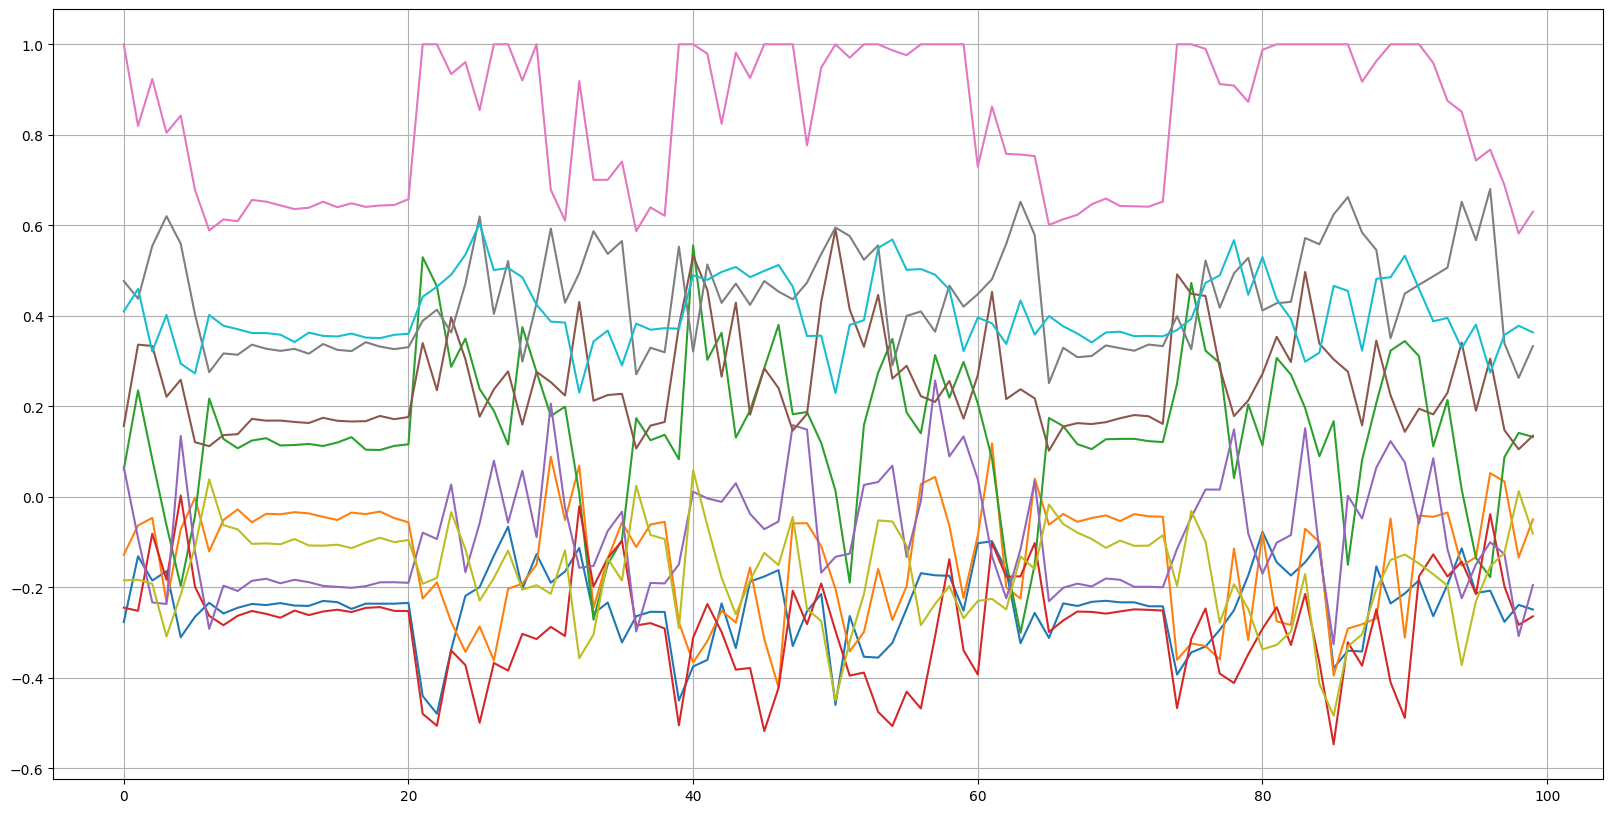

SHAPE: torch.Size([1, 128, 100])


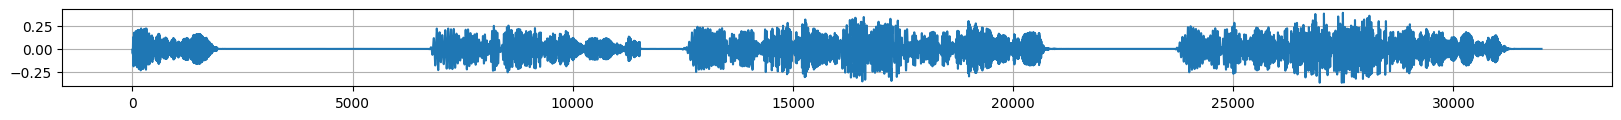

bat num 0 at time 2025-08-29 11:34:24
inp_seq_seq.shape = torch.Size([1, 100, 129])
y_target_seq.shape = torch.Size([1, 100, 4])
conditioning params: tensor([[1.],
        [1.],
        [1.]])  
bat num 1 at time 2025-08-29 11:34:24
inp_seq_seq.shape = torch.Size([1, 100, 129])
y_target_seq.shape = torch.Size([1, 100, 4])
conditioning params: tensor([[0.6000],
        [0.6000],
        [0.6000]])  
finished at 2025-08-29 11:34:24


In [8]:
# just show some stuff 

print("size of dataset is",len(adataset))
print("no. of batches per epoch is", params['batches_per_epoch'])
print("batchsize id  is", params['batch_size'])

samp, target = adataset.rand_sample()  #samp.shape=(T, inputsize+cond_size)

pvect=samp[0, -model_config.cond_size:]
print(f"pvect: {pvect}")
pvect=samp[params['seqLen']-1, -model_config.cond_size:]
print(f"pvect: {pvect}")

inp=samp[:,:-model_config.cond_size]
print(f'inp.shape is {inp.shape}')

# Now grab n=10 random latent components and look at them over time
_, p = inp.shape
# Generate n=10 random indices from 0 to p-1
indices = torch.randperm(p)[:10]
sub_inp = inp[:, indices]
sub_inp.shape


#first print latent sequence
plt.figure(figsize=(20,10)) 
plt.plot(np.arange(len(sub_inp)), sub_inp) #just print one example from the batch
plt.grid()
plt.show()

samp=samp[:, :params['input_size']].T.unsqueeze(0)
print(f'SHAPE: {samp[:,:params['input_size']].shape}')
audiosamps, sr=latents_to_audio_simple(enc_model, samp*params['clamp_val'])
audiosamps=audiosamps[0, 0]

plt.figure(figsize=(20,1)) 
plt.plot(audiosamps) #just print one example from the batch
plt.grid()
plt.show()


n_batches = 1
for bat, (inp_seq, y_target_seq) in enumerate(test_loader):
    print("bat num {} at time {}".format(bat, mydate()))
    print(f"inp_seq_seq.shape = {inp_seq.shape}") 
    print(f"y_target_seq.shape = {y_target_seq.shape}")
    print(f"conditioning params: { inp_seq[ 0,0:3, -len(params['props']):]    }  ")
    if bat >= n_batches :
        break;
print("finished at {}".format(mydate()))

#This is the "rand_samp" plotted above"
Audio(audiosamps, rate=params['sample_rate'])

In [9]:
# Define the training cycle (100% teacher forcing for now)
#*************************************

def train(model,epoch):

 model.train() #put in training mode
 ave_loss_over_steps = 0
 debug_seqs=0

 for batch_num, (inp, target) in enumerate(train_loader):
    debug_seqs += len(inp)
    inp, target = inp.to(device), target.to(device)
    
    hidden = model.init_hidden(params['batch_size'])
    optimizer.zero_grad()
    loss = 0
    
    # Define quantizer weights
    quantizer_weights = [1.0, 0.8, 0.6, 0.4][:params['n_q']]
    
    for i in range(params['seqLen']):  # Causal: one time step at a time
        outputs, hidden = model(inp[:,i,:], hidden, params['batch_size'])
        
        # Per-quantizer weighted loss (keeping the loop for flexibility)
        for j in range(params['n_q']):
            quantizer_loss = criterion(outputs[j], target[:,i,j])
            loss += quantizer_weights[j] * quantizer_loss
    
    # Normalize by sequence length and total weight
    total_weight = sum(quantizer_weights)
    loss = loss / (params['seqLen'] * total_weight)
    
    loss.backward()
    optimizer.step()
    
    ave_loss_per_sample = loss.item()/params['seqLen']   #over each minibatch
    ave_loss_over_steps += ave_loss_per_sample
    
    if batch_num>=(params['batches_per_epoch']-1):
     break

 print(f"Finished epoch number {epoch} with a total of {debug_seqs} debug_seqs")


 if (epoch+1) % log_interval == 0:
     print(f" time: {datetime.now()}, epoch {epoch+1},  Loss: {ave_loss_per_sample:.4f}")
     list_of_losses.append(ave_loss_per_sample)
     writer.add_scalar("Loss/train", ave_loss_per_sample, epoch+1)

 if (epoch+1) % visualize_interval == 0:

     # these two lines address a resource management issues with temporary directories ...  I think....
     torch.cuda.empty_cache()  # if using GPU
     gc.collect()

     result = newgen(model,max_length)
     print(f'plot the audio which has shape {result.shape}')
     plt.figure(figsize=(20,1))
     plt.plot(np.arange(len(result)), result) #just print one example from the batch
     plt.show()
     model.train() #put model back to training mode


 # overwrite the last, and save a numbered checkpoint
 if (epoch + 1) % params['savemodel_interval'] == 0:
    checkpoint_data = {
        'epoch': epoch+1,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict()
    }
    
    # Save numbered checkpoint
    numbered_path = os.path.join(f"{out_dir}/checkpoints", f"checkpoint_{epoch+1}.pt")
    torch.save(checkpoint_data, numbered_path)
    
    # Copy to "last" (much faster than saving twice)
    last_path = os.path.join(f"{out_dir}/checkpoints", "last_checkpoint.pt")
    shutil.copy2(numbered_path, last_path)
    
    print(f"Saved checkpoint at epoch {epoch+1}")

In [10]:
# ---- Create Output Folders ----
if resume_checkpoint != None:
    out_dir = resume_checkpoint
else:
    run_timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    out_dir = os.path.join(params['savemodeldir'], run_timestamp + "_"+savename)
    os.makedirs(out_dir, exist_ok=True)

    os.makedirs(out_dir, exist_ok=True)
    os.makedirs(f"{out_dir}/checkpoints", exist_ok=True)
    os.makedirs(f"{out_dir}/tensorboard", exist_ok=True)


# ---- Save Config ----
#machine readable
torch.save({
    "model_config": model_config,
    "data_config": data_config
}, f"{out_dir}/config.pt")

#human readable
with open(f"{out_dir}/config.txt", "w") as f: 
    f.write("params = " + repr(params) + "\\n")
    f.write("model_config = " + repr(model_config) + "\\n")
    f.write("data_config = " + repr(data_config) + "\\n")

In [11]:
# this is for visualizing learning be showing one example of a generated sequence.
# the model is warmed up with a random sequence from the data set and it's corresponding param vector
from inference import run_inference

def newgen(model,max_length):
    p_inp, _ = next(iter(test_loader)) # don't need targets
    
    x = p_inp[:, :, :params['input_size']].squeeze(0) # no batch
    c = p_inp[:, 0, -model_config.cond_size:]
    c = c.repeat(max_length, 1) 

    print(f'About to call inference with p_inp.shape = {p_inp.shape}, x.shape = {x.shape}, and c.shape = {c.shape}')
    print(f'About to call inference with p_inp.device = {p_inp.device}, x.device = {x.device}, and c.device = {c.device}')

    gen, sr = run_inference(model, enc_model, c.to(device), x.to(device), params['clamp_val'], top_n=3, temperature=1.0, include_warmup_audio=True)
    
    return gen


### Load the model 

In [12]:

rnn = model.gru_audio_model.RNN(model_config).to(device)
    
optimizer = torch.optim.Adam(rnn.parameters(), lr=params['lr'])
criterion = nn.CrossEntropyLoss()

start_epoch=0

if resume_checkpoint:
    checkpoint_path = os.path.join(f"{out_dir}/checkpoints", "last_checkpoint.pt")
    assert os.path.exists(checkpoint_path), f"File {checkpoint_path} does not exist"
    checkpoint = torch.load(checkpoint_path)
    rnn.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    start_epoch = checkpoint['epoch'] + 1
    print(f"Resumed from checkpoint at epoch {start_epoch}")

writer = SummaryWriter(log_dir=f"{out_dir}/tensorboard")

In [13]:
num_trainable_params = sum(p.numel() for p in rnn.parameters() if p.requires_grad)
print(f"Total trainable parameters: {num_trainable_params}")

bd = param_breakdown(rnn, trainable_only=True) #prints out a breakdown of the parameter counts per layter
# pretty print
print(f"latent_proj: {bd['latent_proj']:,}")
print(f"cond_proj:   {bd['cond_proj']:,}")
print(f"GRU total:   {bd['gru_total']:,}")
for k, v in bd['gru_layers'].items():
    print(f"  {k}: {v:,}")
print("Decoders (per head):")
for i, n in enumerate(bd['decoders']):
    print(f"  decoder[{i}]: {n:,}")
print(f"Decoders total: {bd['decoders_total']:,}")
print(f"Model total:    {bd['model_total']:,}")

Total trainable parameters: 260296
latent_proj: 3,096
cond_proj:   48
GRU total:   56,448
  l0/fwd: 14,112
  l1/fwd: 14,112
  l2/fwd: 14,112
  l3/fwd: 14,112
Decoders (per head):
  decoder[0]: 50,176
  decoder[1]: 50,176
  decoder[2]: 50,176
  decoder[3]: 50,176
Decoders total: 200,704
Model total:    260,296


2025-08-29 11:34:24 Starting training...
Finished epoch number 0 with a total of 10000 debug_seqs
 time: 2025-08-29 11:34:34.757812, epoch 1,  Loss: 0.0430
About to call inference with p_inp.shape = torch.Size([1, 100, 129]), x.shape = torch.Size([100, 128]), and c.shape = torch.Size([300, 1])
About to call inference with p_inp.device = cpu, x.device = cpu, and c.device = cpu
Starting latent inference... with codebook_size=1024, n_q=4, cond_size=1
Warming up model hidden state with provided latents...
Generating 300 latent frames...
Latent generation complete. RNN time to generate: 0.68. Converting to audio...
Inference complete - encoding time = 0.08.
plot the audio which has shape (128000,)


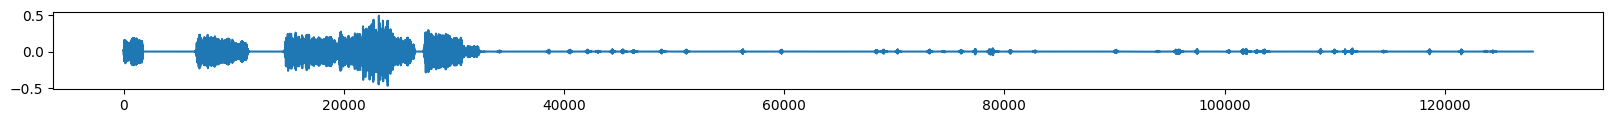

Finished epoch number 1 with a total of 10000 debug_seqs
 time: 2025-08-29 11:34:46.171724, epoch 2,  Loss: 0.0429
About to call inference with p_inp.shape = torch.Size([1, 100, 129]), x.shape = torch.Size([100, 128]), and c.shape = torch.Size([300, 1])
About to call inference with p_inp.device = cpu, x.device = cpu, and c.device = cpu
Starting latent inference... with codebook_size=1024, n_q=4, cond_size=1
Warming up model hidden state with provided latents...
Generating 300 latent frames...
Latent generation complete. RNN time to generate: 0.59. Converting to audio...
Inference complete - encoding time = 0.02.
plot the audio which has shape (128000,)


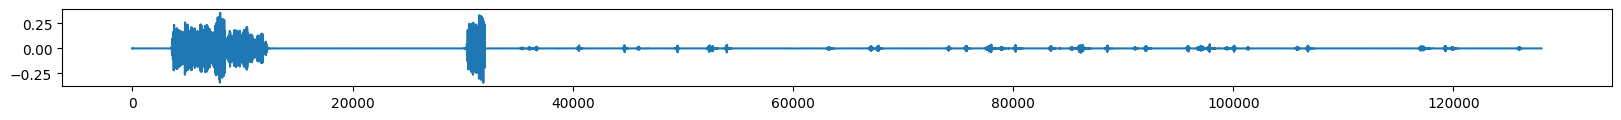

Finished epoch number 2 with a total of 10000 debug_seqs
 time: 2025-08-29 11:34:57.508166, epoch 3,  Loss: 0.0423
About to call inference with p_inp.shape = torch.Size([1, 100, 129]), x.shape = torch.Size([100, 128]), and c.shape = torch.Size([300, 1])
About to call inference with p_inp.device = cpu, x.device = cpu, and c.device = cpu
Starting latent inference... with codebook_size=1024, n_q=4, cond_size=1
Warming up model hidden state with provided latents...
Generating 300 latent frames...
Latent generation complete. RNN time to generate: 0.59. Converting to audio...
Inference complete - encoding time = 0.02.
plot the audio which has shape (128000,)


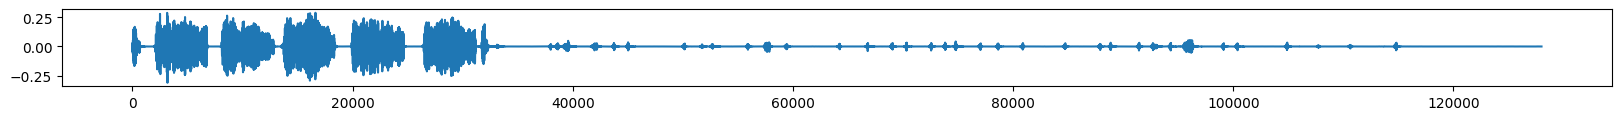

Finished epoch number 3 with a total of 10000 debug_seqs
 time: 2025-08-29 11:35:08.731474, epoch 4,  Loss: 0.0427
About to call inference with p_inp.shape = torch.Size([1, 100, 129]), x.shape = torch.Size([100, 128]), and c.shape = torch.Size([300, 1])
About to call inference with p_inp.device = cpu, x.device = cpu, and c.device = cpu
Starting latent inference... with codebook_size=1024, n_q=4, cond_size=1
Warming up model hidden state with provided latents...
Generating 300 latent frames...
Latent generation complete. RNN time to generate: 0.58. Converting to audio...
Inference complete - encoding time = 0.02.
plot the audio which has shape (128000,)


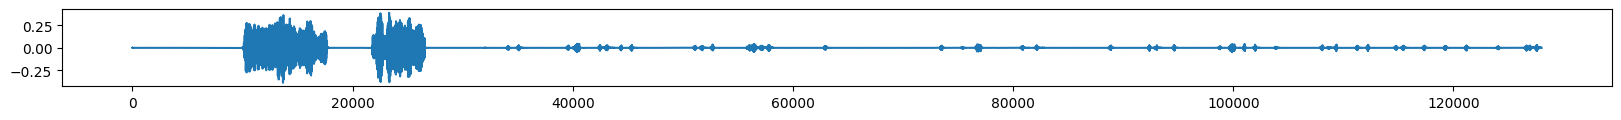

Finished epoch number 4 with a total of 10000 debug_seqs
 time: 2025-08-29 11:35:19.936573, epoch 5,  Loss: 0.0429
About to call inference with p_inp.shape = torch.Size([1, 100, 129]), x.shape = torch.Size([100, 128]), and c.shape = torch.Size([300, 1])
About to call inference with p_inp.device = cpu, x.device = cpu, and c.device = cpu
Starting latent inference... with codebook_size=1024, n_q=4, cond_size=1
Warming up model hidden state with provided latents...
Generating 300 latent frames...
Latent generation complete. RNN time to generate: 0.59. Converting to audio...
Inference complete - encoding time = 0.02.
plot the audio which has shape (128000,)


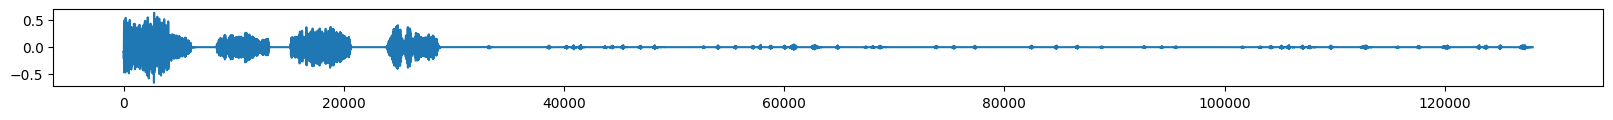

Finished epoch number 5 with a total of 10000 debug_seqs
 time: 2025-08-29 11:35:31.160728, epoch 6,  Loss: 0.0412
About to call inference with p_inp.shape = torch.Size([1, 100, 129]), x.shape = torch.Size([100, 128]), and c.shape = torch.Size([300, 1])
About to call inference with p_inp.device = cpu, x.device = cpu, and c.device = cpu
Starting latent inference... with codebook_size=1024, n_q=4, cond_size=1
Warming up model hidden state with provided latents...
Generating 300 latent frames...
Latent generation complete. RNN time to generate: 0.59. Converting to audio...
Inference complete - encoding time = 0.02.
plot the audio which has shape (128000,)


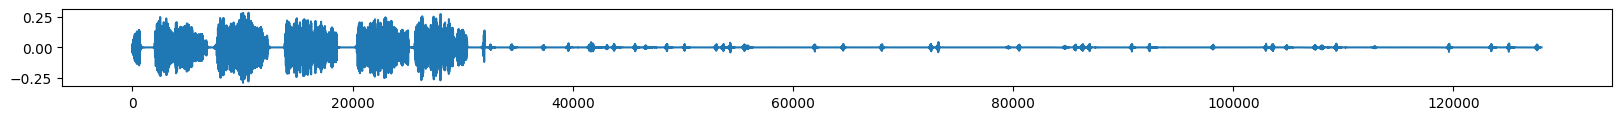

Finished epoch number 6 with a total of 10000 debug_seqs
 time: 2025-08-29 11:35:42.391817, epoch 7,  Loss: 0.0427
About to call inference with p_inp.shape = torch.Size([1, 100, 129]), x.shape = torch.Size([100, 128]), and c.shape = torch.Size([300, 1])
About to call inference with p_inp.device = cpu, x.device = cpu, and c.device = cpu
Starting latent inference... with codebook_size=1024, n_q=4, cond_size=1
Warming up model hidden state with provided latents...
Generating 300 latent frames...
Latent generation complete. RNN time to generate: 0.59. Converting to audio...
Inference complete - encoding time = 0.02.
plot the audio which has shape (128000,)


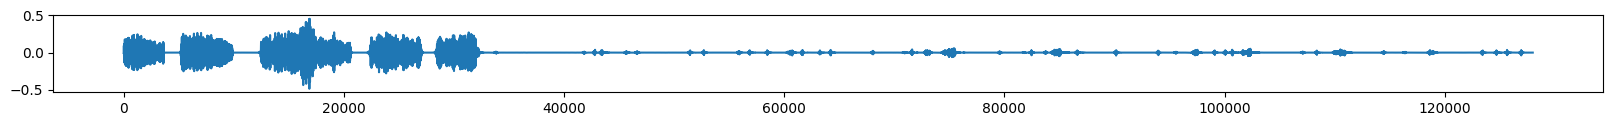

Finished epoch number 7 with a total of 10000 debug_seqs
 time: 2025-08-29 11:35:53.614563, epoch 8,  Loss: 0.0431
About to call inference with p_inp.shape = torch.Size([1, 100, 129]), x.shape = torch.Size([100, 128]), and c.shape = torch.Size([300, 1])
About to call inference with p_inp.device = cpu, x.device = cpu, and c.device = cpu
Starting latent inference... with codebook_size=1024, n_q=4, cond_size=1
Warming up model hidden state with provided latents...
Generating 300 latent frames...
Latent generation complete. RNN time to generate: 0.59. Converting to audio...
Inference complete - encoding time = 0.02.
plot the audio which has shape (128000,)


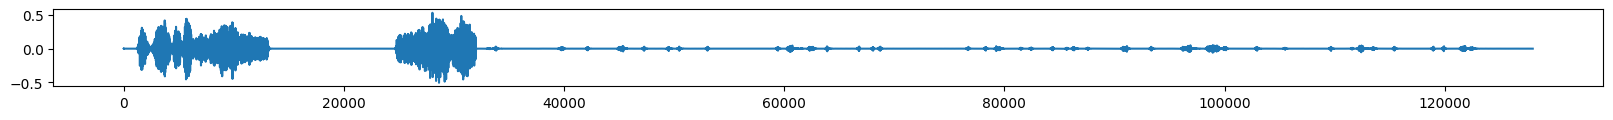

Finished epoch number 8 with a total of 10000 debug_seqs
 time: 2025-08-29 11:36:04.848277, epoch 9,  Loss: 0.0412
About to call inference with p_inp.shape = torch.Size([1, 100, 129]), x.shape = torch.Size([100, 128]), and c.shape = torch.Size([300, 1])
About to call inference with p_inp.device = cpu, x.device = cpu, and c.device = cpu
Starting latent inference... with codebook_size=1024, n_q=4, cond_size=1
Warming up model hidden state with provided latents...
Generating 300 latent frames...
Latent generation complete. RNN time to generate: 0.58. Converting to audio...
Inference complete - encoding time = 0.02.
plot the audio which has shape (128000,)


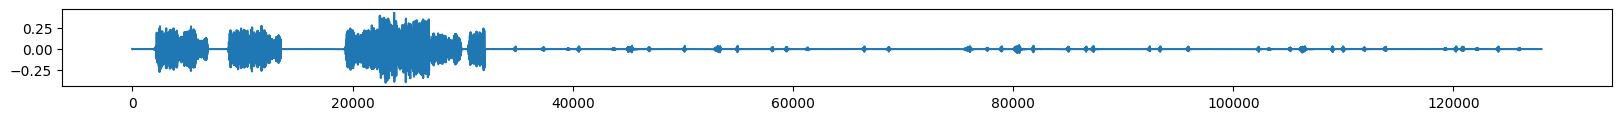

Finished epoch number 9 with a total of 10000 debug_seqs
 time: 2025-08-29 11:36:16.061772, epoch 10,  Loss: 0.0416
About to call inference with p_inp.shape = torch.Size([1, 100, 129]), x.shape = torch.Size([100, 128]), and c.shape = torch.Size([300, 1])
About to call inference with p_inp.device = cpu, x.device = cpu, and c.device = cpu
Starting latent inference... with codebook_size=1024, n_q=4, cond_size=1
Warming up model hidden state with provided latents...
Generating 300 latent frames...
Latent generation complete. RNN time to generate: 0.58. Converting to audio...
Inference complete - encoding time = 0.02.
plot the audio which has shape (128000,)


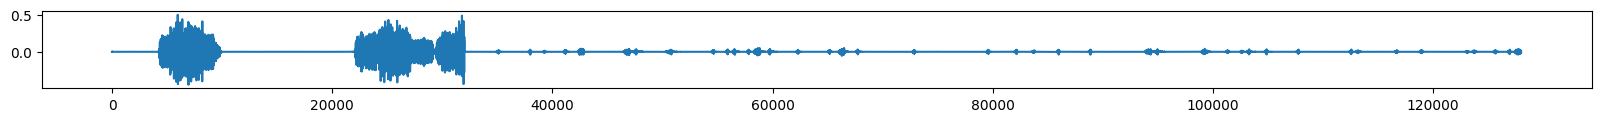

Saved checkpoint at epoch 10
Finished epoch number 10 with a total of 10000 debug_seqs
 time: 2025-08-29 11:36:27.261452, epoch 11,  Loss: 0.0425
About to call inference with p_inp.shape = torch.Size([1, 100, 129]), x.shape = torch.Size([100, 128]), and c.shape = torch.Size([300, 1])
About to call inference with p_inp.device = cpu, x.device = cpu, and c.device = cpu
Starting latent inference... with codebook_size=1024, n_q=4, cond_size=1
Warming up model hidden state with provided latents...
Generating 300 latent frames...
Latent generation complete. RNN time to generate: 0.59. Converting to audio...
Inference complete - encoding time = 0.02.
plot the audio which has shape (128000,)


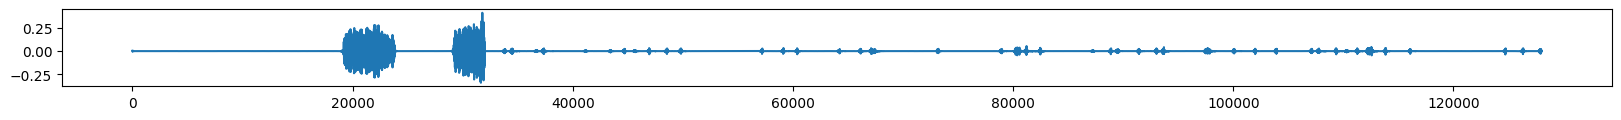

Finished epoch number 11 with a total of 10000 debug_seqs
 time: 2025-08-29 11:36:38.553430, epoch 12,  Loss: 0.0427
About to call inference with p_inp.shape = torch.Size([1, 100, 129]), x.shape = torch.Size([100, 128]), and c.shape = torch.Size([300, 1])
About to call inference with p_inp.device = cpu, x.device = cpu, and c.device = cpu
Starting latent inference... with codebook_size=1024, n_q=4, cond_size=1
Warming up model hidden state with provided latents...
Generating 300 latent frames...
Latent generation complete. RNN time to generate: 0.61. Converting to audio...
Inference complete - encoding time = 0.02.
plot the audio which has shape (128000,)


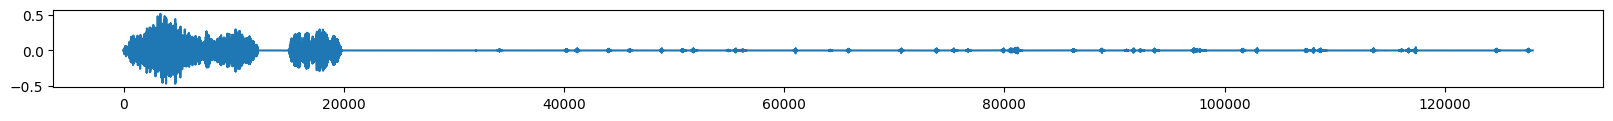

Finished epoch number 12 with a total of 10000 debug_seqs
 time: 2025-08-29 11:36:49.855051, epoch 13,  Loss: 0.0387
About to call inference with p_inp.shape = torch.Size([1, 100, 129]), x.shape = torch.Size([100, 128]), and c.shape = torch.Size([300, 1])
About to call inference with p_inp.device = cpu, x.device = cpu, and c.device = cpu
Starting latent inference... with codebook_size=1024, n_q=4, cond_size=1
Warming up model hidden state with provided latents...
Generating 300 latent frames...
Latent generation complete. RNN time to generate: 0.59. Converting to audio...
Inference complete - encoding time = 0.02.
plot the audio which has shape (128000,)


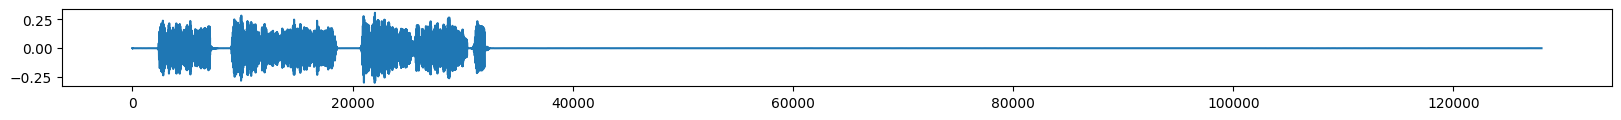

Finished epoch number 13 with a total of 10000 debug_seqs
 time: 2025-08-29 11:37:01.267001, epoch 14,  Loss: 0.0334
About to call inference with p_inp.shape = torch.Size([1, 100, 129]), x.shape = torch.Size([100, 128]), and c.shape = torch.Size([300, 1])
About to call inference with p_inp.device = cpu, x.device = cpu, and c.device = cpu
Starting latent inference... with codebook_size=1024, n_q=4, cond_size=1
Warming up model hidden state with provided latents...
Generating 300 latent frames...
Latent generation complete. RNN time to generate: 0.59. Converting to audio...
Inference complete - encoding time = 0.02.
plot the audio which has shape (128000,)


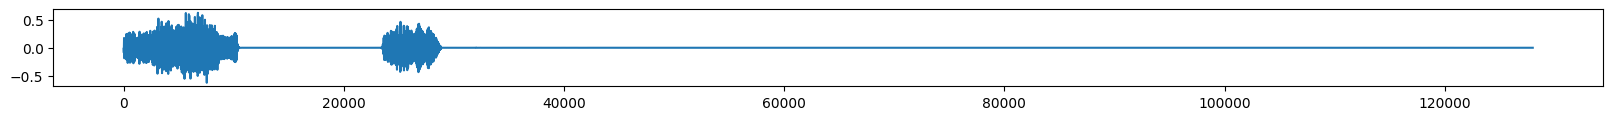

Finished epoch number 14 with a total of 10000 debug_seqs
 time: 2025-08-29 11:37:12.709204, epoch 15,  Loss: 0.0291
About to call inference with p_inp.shape = torch.Size([1, 100, 129]), x.shape = torch.Size([100, 128]), and c.shape = torch.Size([300, 1])
About to call inference with p_inp.device = cpu, x.device = cpu, and c.device = cpu
Starting latent inference... with codebook_size=1024, n_q=4, cond_size=1
Warming up model hidden state with provided latents...
Generating 300 latent frames...
Latent generation complete. RNN time to generate: 0.61. Converting to audio...
Inference complete - encoding time = 0.02.
plot the audio which has shape (128000,)


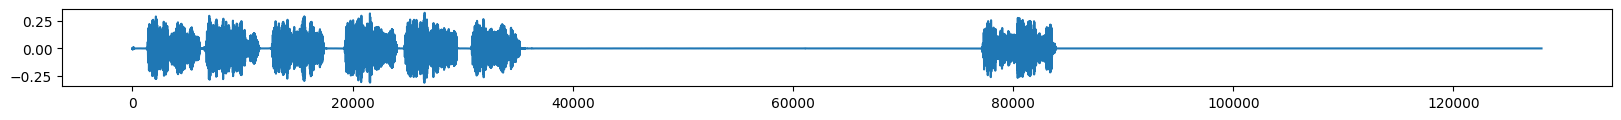

Finished epoch number 15 with a total of 10000 debug_seqs
 time: 2025-08-29 11:37:24.029822, epoch 16,  Loss: 0.0258
About to call inference with p_inp.shape = torch.Size([1, 100, 129]), x.shape = torch.Size([100, 128]), and c.shape = torch.Size([300, 1])
About to call inference with p_inp.device = cpu, x.device = cpu, and c.device = cpu
Starting latent inference... with codebook_size=1024, n_q=4, cond_size=1
Warming up model hidden state with provided latents...
Generating 300 latent frames...
Latent generation complete. RNN time to generate: 0.60. Converting to audio...
Inference complete - encoding time = 0.02.
plot the audio which has shape (128000,)


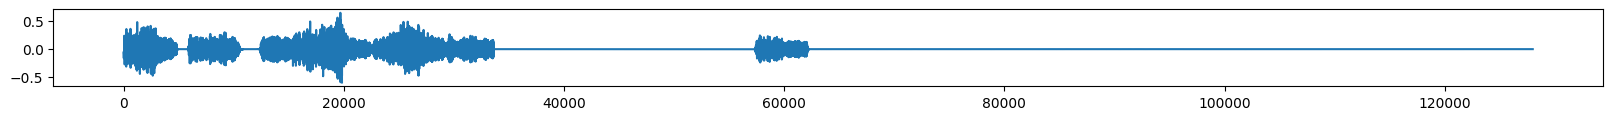

Finished epoch number 16 with a total of 10000 debug_seqs
 time: 2025-08-29 11:37:35.411802, epoch 17,  Loss: 0.0253
About to call inference with p_inp.shape = torch.Size([1, 100, 129]), x.shape = torch.Size([100, 128]), and c.shape = torch.Size([300, 1])
About to call inference with p_inp.device = cpu, x.device = cpu, and c.device = cpu
Starting latent inference... with codebook_size=1024, n_q=4, cond_size=1
Warming up model hidden state with provided latents...
Generating 300 latent frames...
Latent generation complete. RNN time to generate: 0.60. Converting to audio...
Inference complete - encoding time = 0.02.
plot the audio which has shape (128000,)


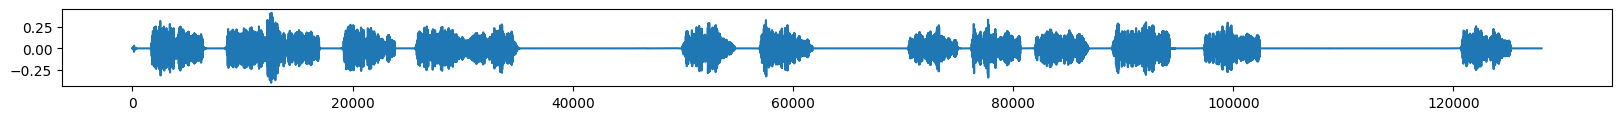

Finished epoch number 17 with a total of 10000 debug_seqs
 time: 2025-08-29 11:37:46.931355, epoch 18,  Loss: 0.0247
About to call inference with p_inp.shape = torch.Size([1, 100, 129]), x.shape = torch.Size([100, 128]), and c.shape = torch.Size([300, 1])
About to call inference with p_inp.device = cpu, x.device = cpu, and c.device = cpu
Starting latent inference... with codebook_size=1024, n_q=4, cond_size=1
Warming up model hidden state with provided latents...
Generating 300 latent frames...
Latent generation complete. RNN time to generate: 0.59. Converting to audio...
Inference complete - encoding time = 0.02.
plot the audio which has shape (128000,)


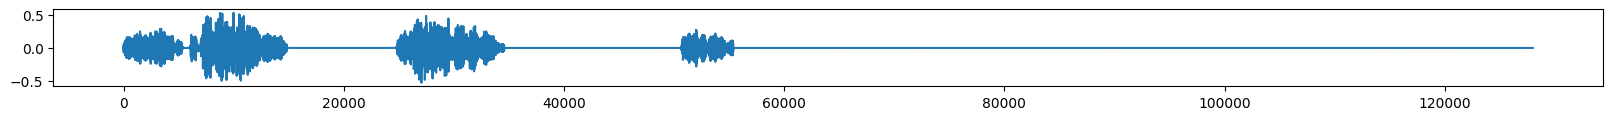

Finished epoch number 18 with a total of 10000 debug_seqs
 time: 2025-08-29 11:37:58.726311, epoch 19,  Loss: 0.0236
About to call inference with p_inp.shape = torch.Size([1, 100, 129]), x.shape = torch.Size([100, 128]), and c.shape = torch.Size([300, 1])
About to call inference with p_inp.device = cpu, x.device = cpu, and c.device = cpu
Starting latent inference... with codebook_size=1024, n_q=4, cond_size=1
Warming up model hidden state with provided latents...
Generating 300 latent frames...
Latent generation complete. RNN time to generate: 0.61. Converting to audio...
Inference complete - encoding time = 0.02.
plot the audio which has shape (128000,)


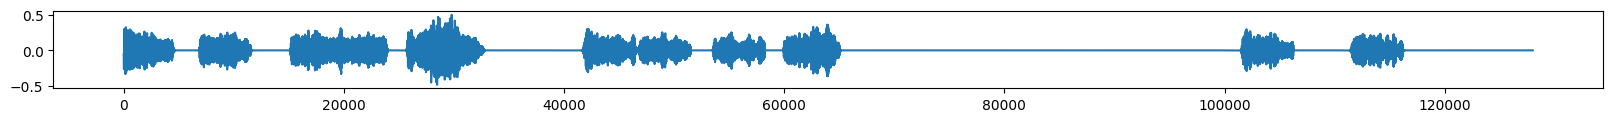

Finished epoch number 19 with a total of 10000 debug_seqs
 time: 2025-08-29 11:38:10.242365, epoch 20,  Loss: 0.0239
About to call inference with p_inp.shape = torch.Size([1, 100, 129]), x.shape = torch.Size([100, 128]), and c.shape = torch.Size([300, 1])
About to call inference with p_inp.device = cpu, x.device = cpu, and c.device = cpu
Starting latent inference... with codebook_size=1024, n_q=4, cond_size=1
Warming up model hidden state with provided latents...
Generating 300 latent frames...
Latent generation complete. RNN time to generate: 0.59. Converting to audio...
Inference complete - encoding time = 0.01.
plot the audio which has shape (128000,)


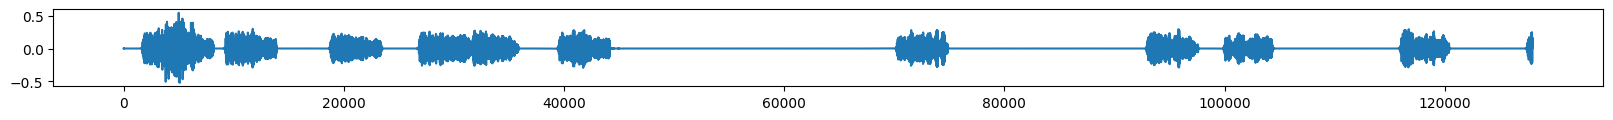

Saved checkpoint at epoch 20
Finished epoch number 20 with a total of 10000 debug_seqs
 time: 2025-08-29 11:38:21.759448, epoch 21,  Loss: 0.0233
About to call inference with p_inp.shape = torch.Size([1, 100, 129]), x.shape = torch.Size([100, 128]), and c.shape = torch.Size([300, 1])
About to call inference with p_inp.device = cpu, x.device = cpu, and c.device = cpu
Starting latent inference... with codebook_size=1024, n_q=4, cond_size=1
Warming up model hidden state with provided latents...
Generating 300 latent frames...
Latent generation complete. RNN time to generate: 0.60. Converting to audio...
Inference complete - encoding time = 0.02.
plot the audio which has shape (128000,)


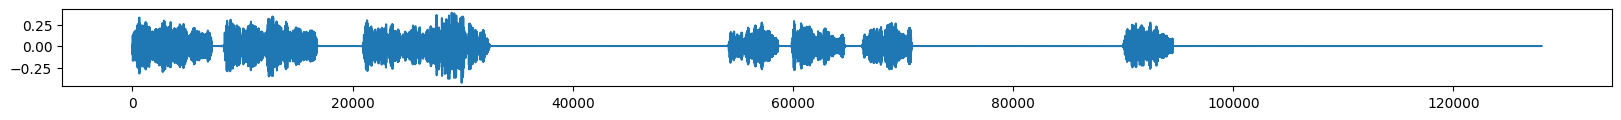

Finished epoch number 21 with a total of 10000 debug_seqs
 time: 2025-08-29 11:38:33.061153, epoch 22,  Loss: 0.0236
About to call inference with p_inp.shape = torch.Size([1, 100, 129]), x.shape = torch.Size([100, 128]), and c.shape = torch.Size([300, 1])
About to call inference with p_inp.device = cpu, x.device = cpu, and c.device = cpu
Starting latent inference... with codebook_size=1024, n_q=4, cond_size=1
Warming up model hidden state with provided latents...
Generating 300 latent frames...
Latent generation complete. RNN time to generate: 0.59. Converting to audio...
Inference complete - encoding time = 0.02.
plot the audio which has shape (128000,)


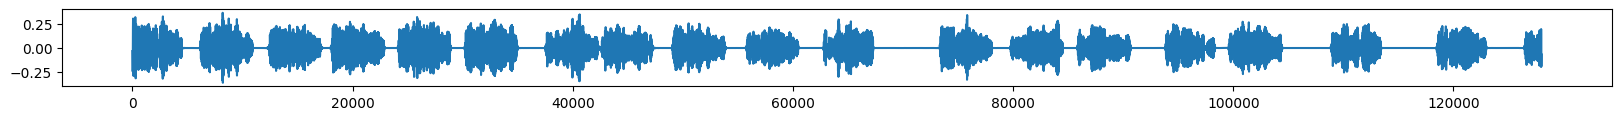

Finished epoch number 22 with a total of 10000 debug_seqs
 time: 2025-08-29 11:38:44.447257, epoch 23,  Loss: 0.0225
About to call inference with p_inp.shape = torch.Size([1, 100, 129]), x.shape = torch.Size([100, 128]), and c.shape = torch.Size([300, 1])
About to call inference with p_inp.device = cpu, x.device = cpu, and c.device = cpu
Starting latent inference... with codebook_size=1024, n_q=4, cond_size=1
Warming up model hidden state with provided latents...
Generating 300 latent frames...
Latent generation complete. RNN time to generate: 0.60. Converting to audio...
Inference complete - encoding time = 0.02.
plot the audio which has shape (128000,)


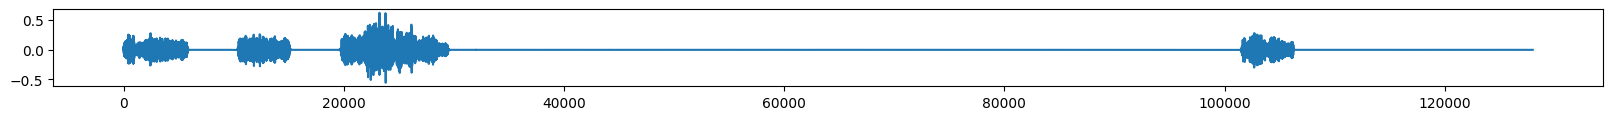

Finished epoch number 23 with a total of 10000 debug_seqs
 time: 2025-08-29 11:38:56.084899, epoch 24,  Loss: 0.0228
About to call inference with p_inp.shape = torch.Size([1, 100, 129]), x.shape = torch.Size([100, 128]), and c.shape = torch.Size([300, 1])
About to call inference with p_inp.device = cpu, x.device = cpu, and c.device = cpu
Starting latent inference... with codebook_size=1024, n_q=4, cond_size=1
Warming up model hidden state with provided latents...
Generating 300 latent frames...
Latent generation complete. RNN time to generate: 0.60. Converting to audio...
Inference complete - encoding time = 0.02.
plot the audio which has shape (128000,)


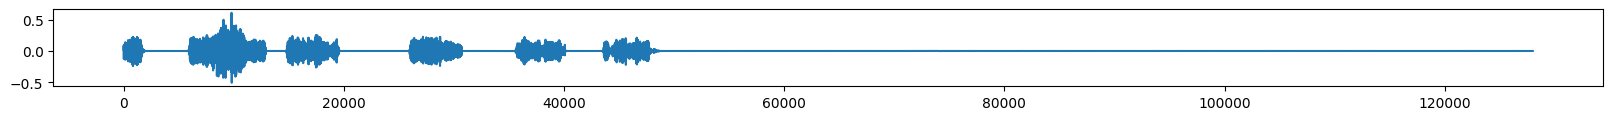

Finished epoch number 24 with a total of 10000 debug_seqs
 time: 2025-08-29 11:39:07.604801, epoch 25,  Loss: 0.0232
About to call inference with p_inp.shape = torch.Size([1, 100, 129]), x.shape = torch.Size([100, 128]), and c.shape = torch.Size([300, 1])
About to call inference with p_inp.device = cpu, x.device = cpu, and c.device = cpu
Starting latent inference... with codebook_size=1024, n_q=4, cond_size=1
Warming up model hidden state with provided latents...
Generating 300 latent frames...
Latent generation complete. RNN time to generate: 0.59. Converting to audio...
Inference complete - encoding time = 0.02.
plot the audio which has shape (128000,)


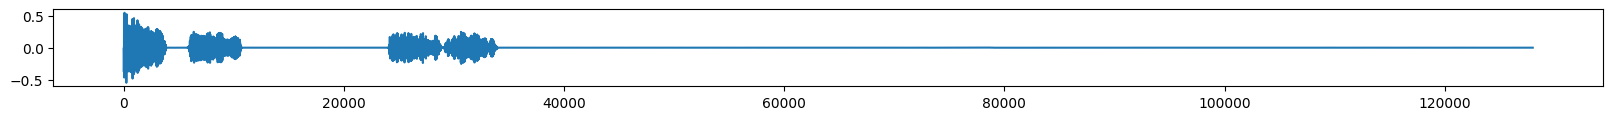

Finished epoch number 25 with a total of 10000 debug_seqs
 time: 2025-08-29 11:39:19.058242, epoch 26,  Loss: 0.0224
About to call inference with p_inp.shape = torch.Size([1, 100, 129]), x.shape = torch.Size([100, 128]), and c.shape = torch.Size([300, 1])
About to call inference with p_inp.device = cpu, x.device = cpu, and c.device = cpu
Starting latent inference... with codebook_size=1024, n_q=4, cond_size=1
Warming up model hidden state with provided latents...
Generating 300 latent frames...
Latent generation complete. RNN time to generate: 0.59. Converting to audio...
Inference complete - encoding time = 0.02.
plot the audio which has shape (128000,)


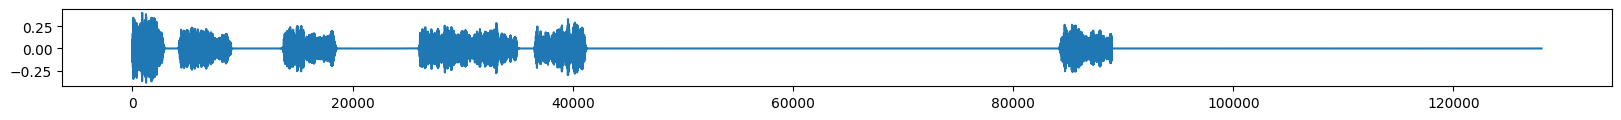

Finished epoch number 26 with a total of 10000 debug_seqs
 time: 2025-08-29 11:39:30.420882, epoch 27,  Loss: 0.0220
About to call inference with p_inp.shape = torch.Size([1, 100, 129]), x.shape = torch.Size([100, 128]), and c.shape = torch.Size([300, 1])
About to call inference with p_inp.device = cpu, x.device = cpu, and c.device = cpu
Starting latent inference... with codebook_size=1024, n_q=4, cond_size=1
Warming up model hidden state with provided latents...
Generating 300 latent frames...
Latent generation complete. RNN time to generate: 0.59. Converting to audio...
Inference complete - encoding time = 0.02.
plot the audio which has shape (128000,)


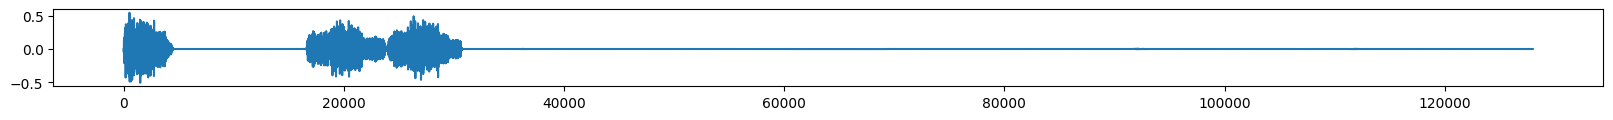

Finished epoch number 27 with a total of 10000 debug_seqs
 time: 2025-08-29 11:39:41.875606, epoch 28,  Loss: 0.0223
About to call inference with p_inp.shape = torch.Size([1, 100, 129]), x.shape = torch.Size([100, 128]), and c.shape = torch.Size([300, 1])
About to call inference with p_inp.device = cpu, x.device = cpu, and c.device = cpu
Starting latent inference... with codebook_size=1024, n_q=4, cond_size=1
Warming up model hidden state with provided latents...
Generating 300 latent frames...
Latent generation complete. RNN time to generate: 0.59. Converting to audio...
Inference complete - encoding time = 0.02.
plot the audio which has shape (128000,)


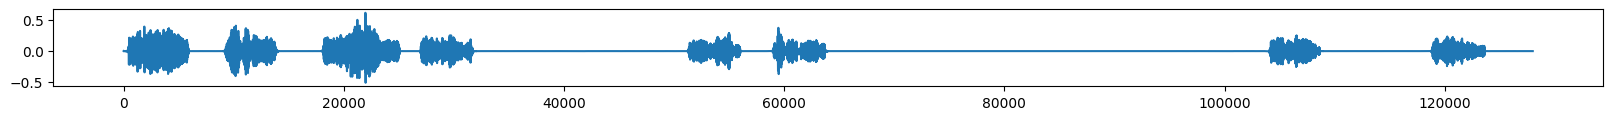

Finished epoch number 28 with a total of 10000 debug_seqs
 time: 2025-08-29 11:39:53.306686, epoch 29,  Loss: 0.0228
About to call inference with p_inp.shape = torch.Size([1, 100, 129]), x.shape = torch.Size([100, 128]), and c.shape = torch.Size([300, 1])
About to call inference with p_inp.device = cpu, x.device = cpu, and c.device = cpu
Starting latent inference... with codebook_size=1024, n_q=4, cond_size=1
Warming up model hidden state with provided latents...
Generating 300 latent frames...
Latent generation complete. RNN time to generate: 0.61. Converting to audio...
Inference complete - encoding time = 0.02.
plot the audio which has shape (128000,)


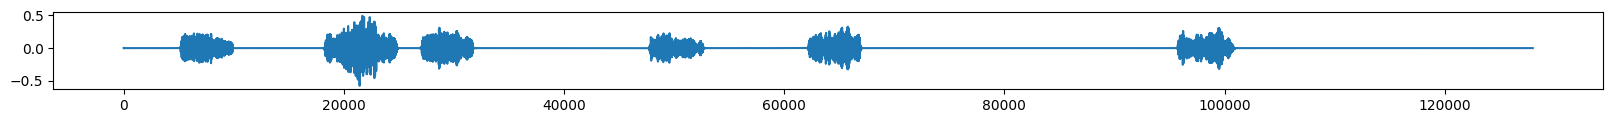

Finished epoch number 29 with a total of 10000 debug_seqs
 time: 2025-08-29 11:40:05.001136, epoch 30,  Loss: 0.0224
About to call inference with p_inp.shape = torch.Size([1, 100, 129]), x.shape = torch.Size([100, 128]), and c.shape = torch.Size([300, 1])
About to call inference with p_inp.device = cpu, x.device = cpu, and c.device = cpu
Starting latent inference... with codebook_size=1024, n_q=4, cond_size=1
Warming up model hidden state with provided latents...
Generating 300 latent frames...
Latent generation complete. RNN time to generate: 0.62. Converting to audio...
Inference complete - encoding time = 0.02.
plot the audio which has shape (128000,)


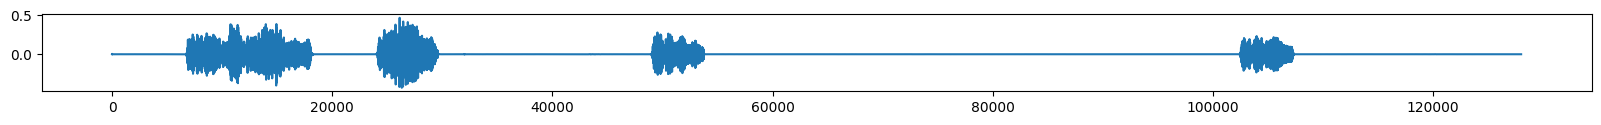

Saved checkpoint at epoch 30
Finished epoch number 30 with a total of 10000 debug_seqs
 time: 2025-08-29 11:40:16.748358, epoch 31,  Loss: 0.0227
About to call inference with p_inp.shape = torch.Size([1, 100, 129]), x.shape = torch.Size([100, 128]), and c.shape = torch.Size([300, 1])
About to call inference with p_inp.device = cpu, x.device = cpu, and c.device = cpu
Starting latent inference... with codebook_size=1024, n_q=4, cond_size=1
Warming up model hidden state with provided latents...
Generating 300 latent frames...
Latent generation complete. RNN time to generate: 0.62. Converting to audio...
Inference complete - encoding time = 0.02.
plot the audio which has shape (128000,)


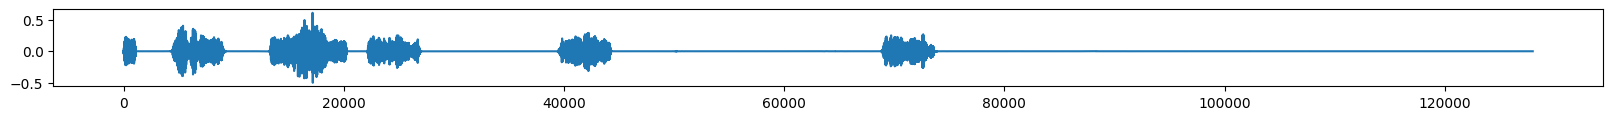

Finished epoch number 31 with a total of 10000 debug_seqs
 time: 2025-08-29 11:40:28.466452, epoch 32,  Loss: 0.0226
About to call inference with p_inp.shape = torch.Size([1, 100, 129]), x.shape = torch.Size([100, 128]), and c.shape = torch.Size([300, 1])
About to call inference with p_inp.device = cpu, x.device = cpu, and c.device = cpu
Starting latent inference... with codebook_size=1024, n_q=4, cond_size=1
Warming up model hidden state with provided latents...
Generating 300 latent frames...
Latent generation complete. RNN time to generate: 0.61. Converting to audio...
Inference complete - encoding time = 0.02.
plot the audio which has shape (128000,)


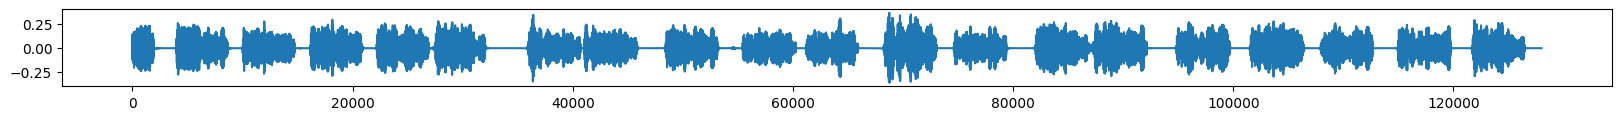

Finished epoch number 32 with a total of 10000 debug_seqs
 time: 2025-08-29 11:40:40.208147, epoch 33,  Loss: 0.0223
About to call inference with p_inp.shape = torch.Size([1, 100, 129]), x.shape = torch.Size([100, 128]), and c.shape = torch.Size([300, 1])
About to call inference with p_inp.device = cpu, x.device = cpu, and c.device = cpu
Starting latent inference... with codebook_size=1024, n_q=4, cond_size=1
Warming up model hidden state with provided latents...
Generating 300 latent frames...
Latent generation complete. RNN time to generate: 0.60. Converting to audio...
Inference complete - encoding time = 0.02.
plot the audio which has shape (128000,)


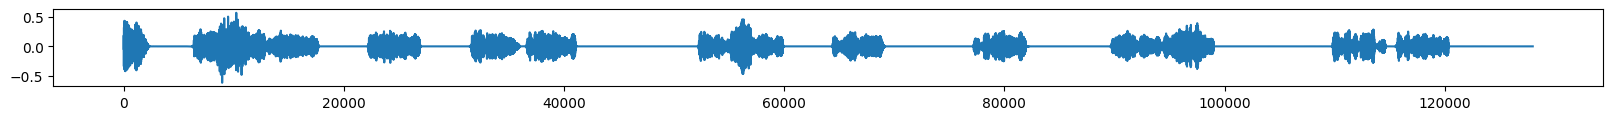

Finished epoch number 33 with a total of 10000 debug_seqs
 time: 2025-08-29 11:40:51.849843, epoch 34,  Loss: 0.0224
About to call inference with p_inp.shape = torch.Size([1, 100, 129]), x.shape = torch.Size([100, 128]), and c.shape = torch.Size([300, 1])
About to call inference with p_inp.device = cpu, x.device = cpu, and c.device = cpu
Starting latent inference... with codebook_size=1024, n_q=4, cond_size=1
Warming up model hidden state with provided latents...
Generating 300 latent frames...
Latent generation complete. RNN time to generate: 0.60. Converting to audio...
Inference complete - encoding time = 0.02.
plot the audio which has shape (128000,)


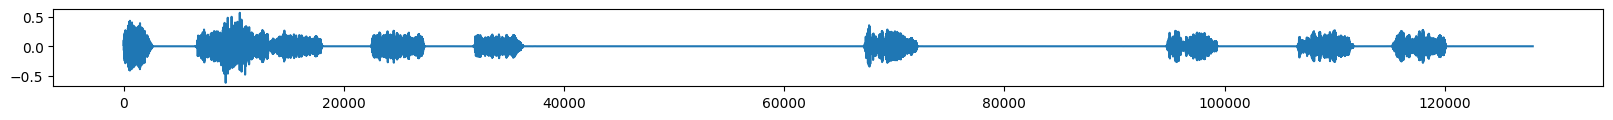

Finished epoch number 34 with a total of 10000 debug_seqs
 time: 2025-08-29 11:41:03.474393, epoch 35,  Loss: 0.0231
About to call inference with p_inp.shape = torch.Size([1, 100, 129]), x.shape = torch.Size([100, 128]), and c.shape = torch.Size([300, 1])
About to call inference with p_inp.device = cpu, x.device = cpu, and c.device = cpu
Starting latent inference... with codebook_size=1024, n_q=4, cond_size=1
Warming up model hidden state with provided latents...
Generating 300 latent frames...
Latent generation complete. RNN time to generate: 0.61. Converting to audio...
Inference complete - encoding time = 0.02.
plot the audio which has shape (128000,)


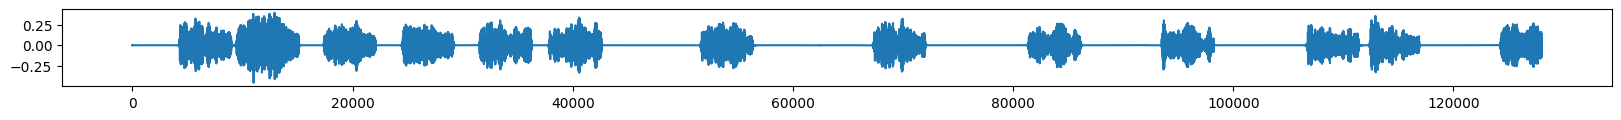

Finished epoch number 35 with a total of 10000 debug_seqs
 time: 2025-08-29 11:41:15.072655, epoch 36,  Loss: 0.0221
About to call inference with p_inp.shape = torch.Size([1, 100, 129]), x.shape = torch.Size([100, 128]), and c.shape = torch.Size([300, 1])
About to call inference with p_inp.device = cpu, x.device = cpu, and c.device = cpu
Starting latent inference... with codebook_size=1024, n_q=4, cond_size=1
Warming up model hidden state with provided latents...
Generating 300 latent frames...
Latent generation complete. RNN time to generate: 0.60. Converting to audio...
Inference complete - encoding time = 0.02.
plot the audio which has shape (128000,)


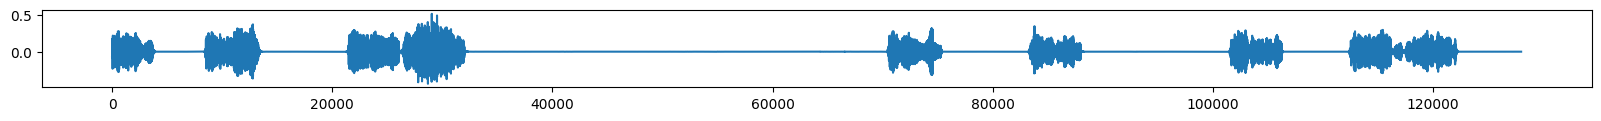

Finished epoch number 36 with a total of 10000 debug_seqs
 time: 2025-08-29 11:41:26.661672, epoch 37,  Loss: 0.0218
About to call inference with p_inp.shape = torch.Size([1, 100, 129]), x.shape = torch.Size([100, 128]), and c.shape = torch.Size([300, 1])
About to call inference with p_inp.device = cpu, x.device = cpu, and c.device = cpu
Starting latent inference... with codebook_size=1024, n_q=4, cond_size=1
Warming up model hidden state with provided latents...
Generating 300 latent frames...
Latent generation complete. RNN time to generate: 0.61. Converting to audio...
Inference complete - encoding time = 0.02.
plot the audio which has shape (128000,)


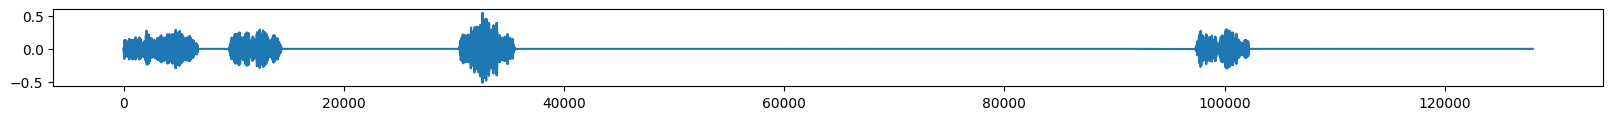

Finished epoch number 37 with a total of 10000 debug_seqs
 time: 2025-08-29 11:41:38.243256, epoch 38,  Loss: 0.0224
About to call inference with p_inp.shape = torch.Size([1, 100, 129]), x.shape = torch.Size([100, 128]), and c.shape = torch.Size([300, 1])
About to call inference with p_inp.device = cpu, x.device = cpu, and c.device = cpu
Starting latent inference... with codebook_size=1024, n_q=4, cond_size=1
Warming up model hidden state with provided latents...
Generating 300 latent frames...
Latent generation complete. RNN time to generate: 0.62. Converting to audio...
Inference complete - encoding time = 0.02.
plot the audio which has shape (128000,)


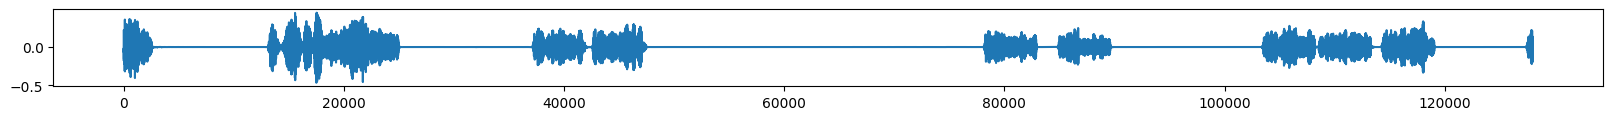

Finished epoch number 38 with a total of 10000 debug_seqs
 time: 2025-08-29 11:41:49.846670, epoch 39,  Loss: 0.0220
About to call inference with p_inp.shape = torch.Size([1, 100, 129]), x.shape = torch.Size([100, 128]), and c.shape = torch.Size([300, 1])
About to call inference with p_inp.device = cpu, x.device = cpu, and c.device = cpu
Starting latent inference... with codebook_size=1024, n_q=4, cond_size=1
Warming up model hidden state with provided latents...
Generating 300 latent frames...
Latent generation complete. RNN time to generate: 0.62. Converting to audio...
Inference complete - encoding time = 0.02.
plot the audio which has shape (128000,)


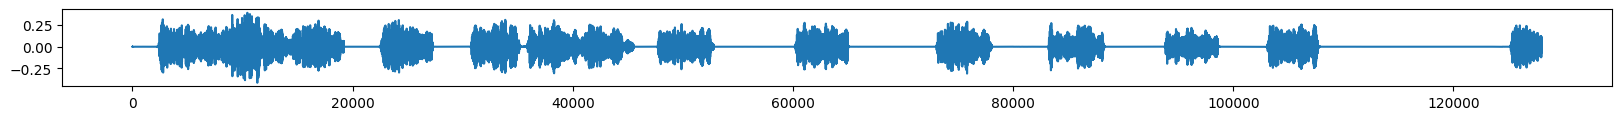

Finished epoch number 39 with a total of 10000 debug_seqs
 time: 2025-08-29 11:42:01.672043, epoch 40,  Loss: 0.0217
About to call inference with p_inp.shape = torch.Size([1, 100, 129]), x.shape = torch.Size([100, 128]), and c.shape = torch.Size([300, 1])
About to call inference with p_inp.device = cpu, x.device = cpu, and c.device = cpu
Starting latent inference... with codebook_size=1024, n_q=4, cond_size=1
Warming up model hidden state with provided latents...
Generating 300 latent frames...
Latent generation complete. RNN time to generate: 0.61. Converting to audio...
Inference complete - encoding time = 0.02.
plot the audio which has shape (128000,)


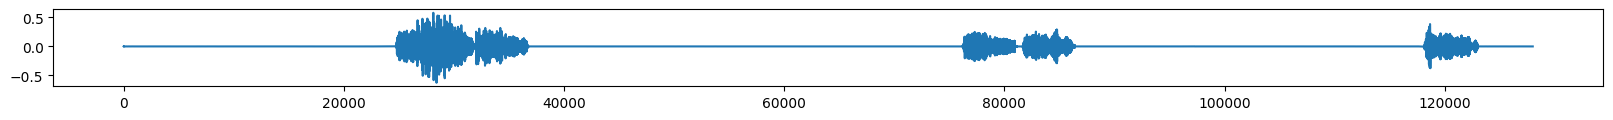

Saved checkpoint at epoch 40
Finished epoch number 40 with a total of 10000 debug_seqs
 time: 2025-08-29 11:42:13.339420, epoch 41,  Loss: 0.0218
About to call inference with p_inp.shape = torch.Size([1, 100, 129]), x.shape = torch.Size([100, 128]), and c.shape = torch.Size([300, 1])
About to call inference with p_inp.device = cpu, x.device = cpu, and c.device = cpu
Starting latent inference... with codebook_size=1024, n_q=4, cond_size=1
Warming up model hidden state with provided latents...
Generating 300 latent frames...
Latent generation complete. RNN time to generate: 0.61. Converting to audio...
Inference complete - encoding time = 0.02.
plot the audio which has shape (128000,)


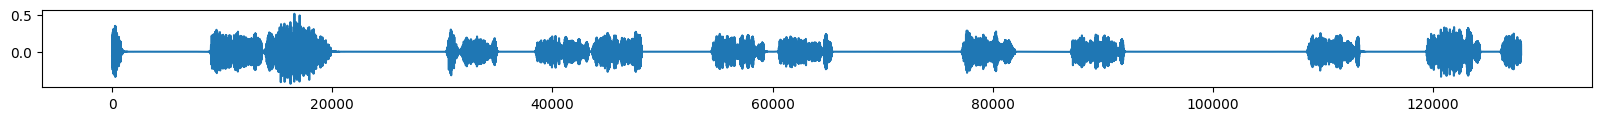

Finished epoch number 41 with a total of 10000 debug_seqs
 time: 2025-08-29 11:42:25.041634, epoch 42,  Loss: 0.0221
About to call inference with p_inp.shape = torch.Size([1, 100, 129]), x.shape = torch.Size([100, 128]), and c.shape = torch.Size([300, 1])
About to call inference with p_inp.device = cpu, x.device = cpu, and c.device = cpu
Starting latent inference... with codebook_size=1024, n_q=4, cond_size=1
Warming up model hidden state with provided latents...
Generating 300 latent frames...
Latent generation complete. RNN time to generate: 0.61. Converting to audio...
Inference complete - encoding time = 0.02.
plot the audio which has shape (128000,)


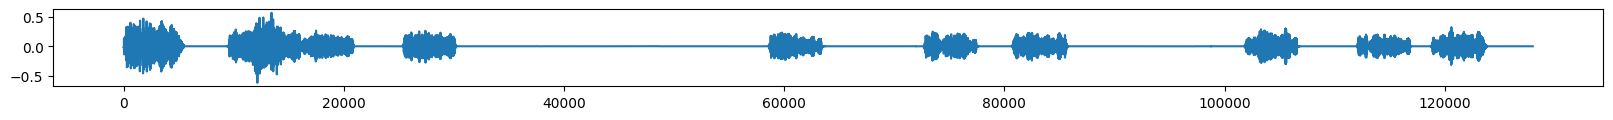

Finished epoch number 42 with a total of 10000 debug_seqs
 time: 2025-08-29 11:42:36.858439, epoch 43,  Loss: 0.0226
About to call inference with p_inp.shape = torch.Size([1, 100, 129]), x.shape = torch.Size([100, 128]), and c.shape = torch.Size([300, 1])
About to call inference with p_inp.device = cpu, x.device = cpu, and c.device = cpu
Starting latent inference... with codebook_size=1024, n_q=4, cond_size=1
Warming up model hidden state with provided latents...
Generating 300 latent frames...
Latent generation complete. RNN time to generate: 0.62. Converting to audio...
Inference complete - encoding time = 0.02.
plot the audio which has shape (128000,)


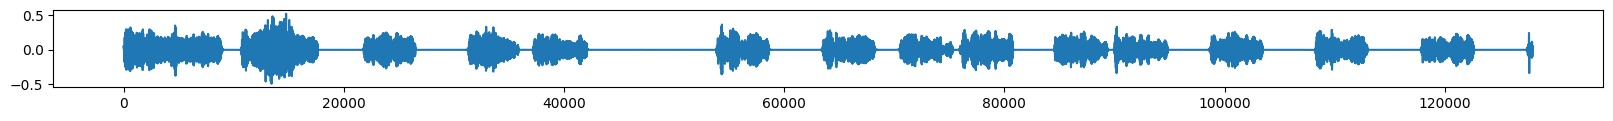

Finished epoch number 43 with a total of 10000 debug_seqs
 time: 2025-08-29 11:42:48.595018, epoch 44,  Loss: 0.0222
About to call inference with p_inp.shape = torch.Size([1, 100, 129]), x.shape = torch.Size([100, 128]), and c.shape = torch.Size([300, 1])
About to call inference with p_inp.device = cpu, x.device = cpu, and c.device = cpu
Starting latent inference... with codebook_size=1024, n_q=4, cond_size=1
Warming up model hidden state with provided latents...
Generating 300 latent frames...
Latent generation complete. RNN time to generate: 0.61. Converting to audio...
Inference complete - encoding time = 0.02.
plot the audio which has shape (128000,)


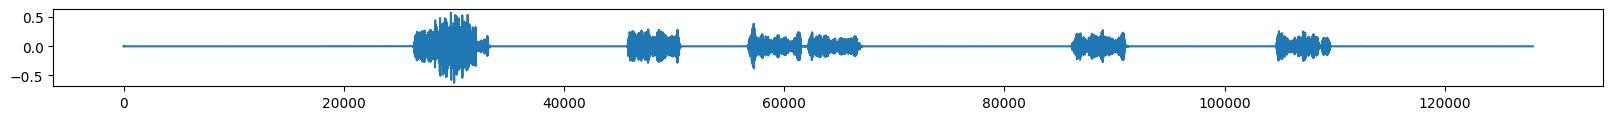

Finished epoch number 44 with a total of 10000 debug_seqs
 time: 2025-08-29 11:43:09.699947, epoch 45,  Loss: 0.0214
About to call inference with p_inp.shape = torch.Size([1, 100, 129]), x.shape = torch.Size([100, 128]), and c.shape = torch.Size([300, 1])
About to call inference with p_inp.device = cpu, x.device = cpu, and c.device = cpu
Starting latent inference... with codebook_size=1024, n_q=4, cond_size=1
Warming up model hidden state with provided latents...
Generating 300 latent frames...
Latent generation complete. RNN time to generate: 2.51. Converting to audio...
Inference complete - encoding time = 0.10.
plot the audio which has shape (128000,)


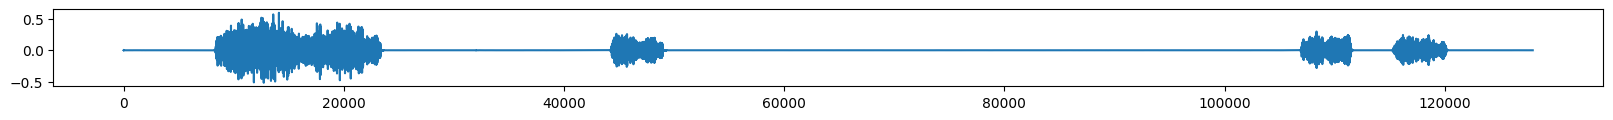

Finished epoch number 45 with a total of 10000 debug_seqs
 time: 2025-08-29 11:43:41.290850, epoch 46,  Loss: 0.0218
About to call inference with p_inp.shape = torch.Size([1, 100, 129]), x.shape = torch.Size([100, 128]), and c.shape = torch.Size([300, 1])
About to call inference with p_inp.device = cpu, x.device = cpu, and c.device = cpu
Starting latent inference... with codebook_size=1024, n_q=4, cond_size=1
Warming up model hidden state with provided latents...
Generating 300 latent frames...
Latent generation complete. RNN time to generate: 2.52. Converting to audio...
Inference complete - encoding time = 0.02.
plot the audio which has shape (128000,)


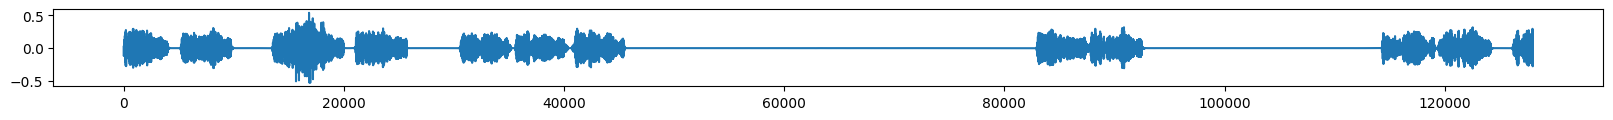

Finished epoch number 46 with a total of 10000 debug_seqs
 time: 2025-08-29 11:44:12.274722, epoch 47,  Loss: 0.0215
About to call inference with p_inp.shape = torch.Size([1, 100, 129]), x.shape = torch.Size([100, 128]), and c.shape = torch.Size([300, 1])
About to call inference with p_inp.device = cpu, x.device = cpu, and c.device = cpu
Starting latent inference... with codebook_size=1024, n_q=4, cond_size=1
Warming up model hidden state with provided latents...
Generating 300 latent frames...
Latent generation complete. RNN time to generate: 2.69. Converting to audio...
Inference complete - encoding time = 0.16.
plot the audio which has shape (128000,)


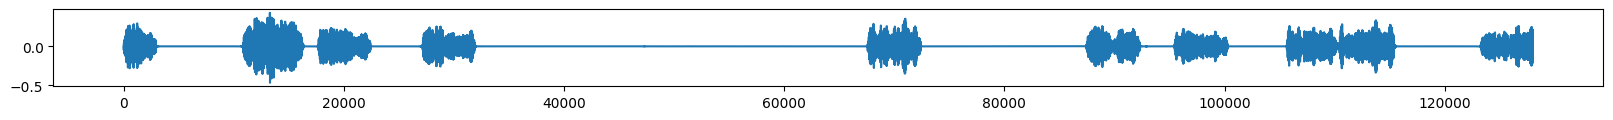

Finished epoch number 47 with a total of 10000 debug_seqs
 time: 2025-08-29 11:44:43.214766, epoch 48,  Loss: 0.0214
About to call inference with p_inp.shape = torch.Size([1, 100, 129]), x.shape = torch.Size([100, 128]), and c.shape = torch.Size([300, 1])
About to call inference with p_inp.device = cpu, x.device = cpu, and c.device = cpu
Starting latent inference... with codebook_size=1024, n_q=4, cond_size=1
Warming up model hidden state with provided latents...
Generating 300 latent frames...
Latent generation complete. RNN time to generate: 2.36. Converting to audio...
Inference complete - encoding time = 0.02.
plot the audio which has shape (128000,)


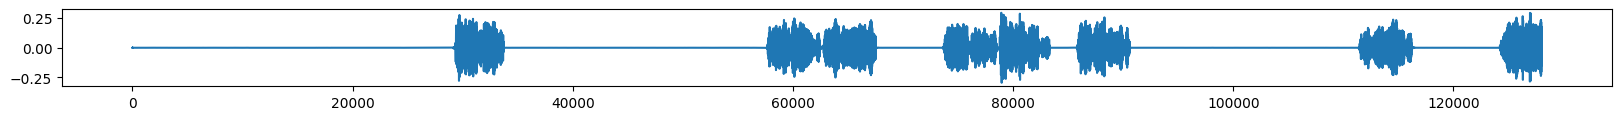

Finished epoch number 48 with a total of 10000 debug_seqs
 time: 2025-08-29 11:45:14.620627, epoch 49,  Loss: 0.0220
About to call inference with p_inp.shape = torch.Size([1, 100, 129]), x.shape = torch.Size([100, 128]), and c.shape = torch.Size([300, 1])
About to call inference with p_inp.device = cpu, x.device = cpu, and c.device = cpu
Starting latent inference... with codebook_size=1024, n_q=4, cond_size=1
Warming up model hidden state with provided latents...
Generating 300 latent frames...
Latent generation complete. RNN time to generate: 2.23. Converting to audio...
Inference complete - encoding time = 0.11.
plot the audio which has shape (128000,)


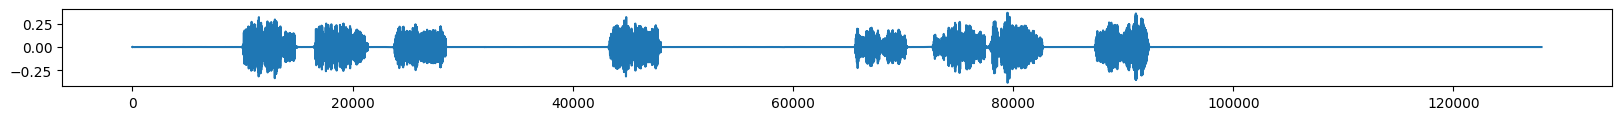

Finished epoch number 49 with a total of 10000 debug_seqs
 time: 2025-08-29 11:45:45.676346, epoch 50,  Loss: 0.0220
About to call inference with p_inp.shape = torch.Size([1, 100, 129]), x.shape = torch.Size([100, 128]), and c.shape = torch.Size([300, 1])
About to call inference with p_inp.device = cpu, x.device = cpu, and c.device = cpu
Starting latent inference... with codebook_size=1024, n_q=4, cond_size=1
Warming up model hidden state with provided latents...
Generating 300 latent frames...
Latent generation complete. RNN time to generate: 2.16. Converting to audio...
Inference complete - encoding time = 0.16.
plot the audio which has shape (128000,)


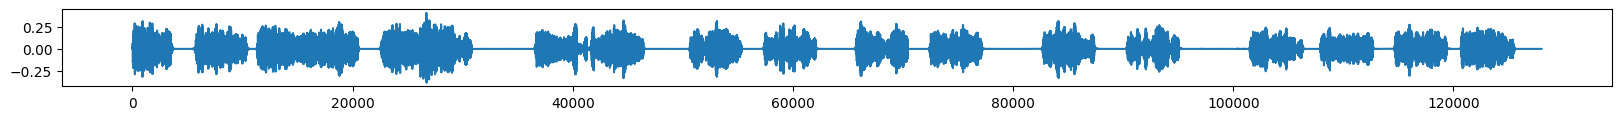

Saved checkpoint at epoch 50
Finished epoch number 50 with a total of 10000 debug_seqs
 time: 2025-08-29 11:46:17.353791, epoch 51,  Loss: 0.0218
About to call inference with p_inp.shape = torch.Size([1, 100, 129]), x.shape = torch.Size([100, 128]), and c.shape = torch.Size([300, 1])
About to call inference with p_inp.device = cpu, x.device = cpu, and c.device = cpu
Starting latent inference... with codebook_size=1024, n_q=4, cond_size=1
Warming up model hidden state with provided latents...
Generating 300 latent frames...
Latent generation complete. RNN time to generate: 1.76. Converting to audio...
Inference complete - encoding time = 0.08.
plot the audio which has shape (128000,)


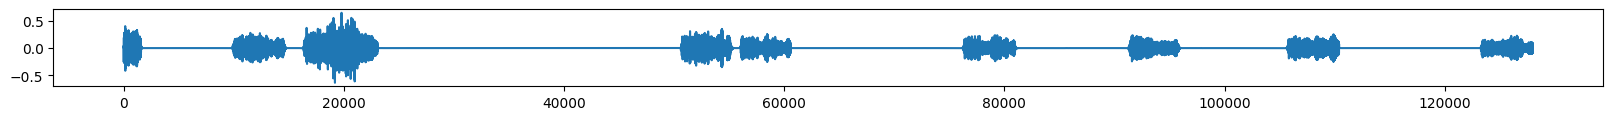

Finished epoch number 51 with a total of 10000 debug_seqs
 time: 2025-08-29 11:46:43.261214, epoch 52,  Loss: 0.0215
About to call inference with p_inp.shape = torch.Size([1, 100, 129]), x.shape = torch.Size([100, 128]), and c.shape = torch.Size([300, 1])
About to call inference with p_inp.device = cpu, x.device = cpu, and c.device = cpu
Starting latent inference... with codebook_size=1024, n_q=4, cond_size=1
Warming up model hidden state with provided latents...
Generating 300 latent frames...
Latent generation complete. RNN time to generate: 2.01. Converting to audio...
Inference complete - encoding time = 0.02.
plot the audio which has shape (128000,)


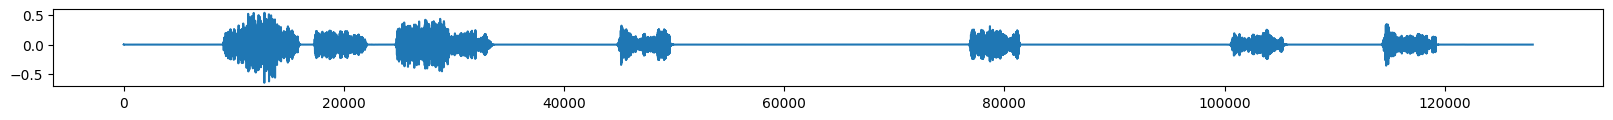

Finished epoch number 52 with a total of 10000 debug_seqs
 time: 2025-08-29 11:47:12.063500, epoch 53,  Loss: 0.0209
About to call inference with p_inp.shape = torch.Size([1, 100, 129]), x.shape = torch.Size([100, 128]), and c.shape = torch.Size([300, 1])
About to call inference with p_inp.device = cpu, x.device = cpu, and c.device = cpu
Starting latent inference... with codebook_size=1024, n_q=4, cond_size=1
Warming up model hidden state with provided latents...
Generating 300 latent frames...
Latent generation complete. RNN time to generate: 2.56. Converting to audio...
Inference complete - encoding time = 0.07.
plot the audio which has shape (128000,)


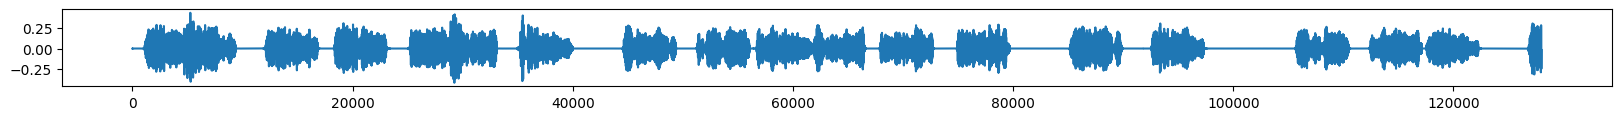

Finished epoch number 53 with a total of 10000 debug_seqs
 time: 2025-08-29 11:47:44.441442, epoch 54,  Loss: 0.0220
About to call inference with p_inp.shape = torch.Size([1, 100, 129]), x.shape = torch.Size([100, 128]), and c.shape = torch.Size([300, 1])
About to call inference with p_inp.device = cpu, x.device = cpu, and c.device = cpu
Starting latent inference... with codebook_size=1024, n_q=4, cond_size=1
Warming up model hidden state with provided latents...
Generating 300 latent frames...
Latent generation complete. RNN time to generate: 2.68. Converting to audio...
Inference complete - encoding time = 0.02.
plot the audio which has shape (128000,)


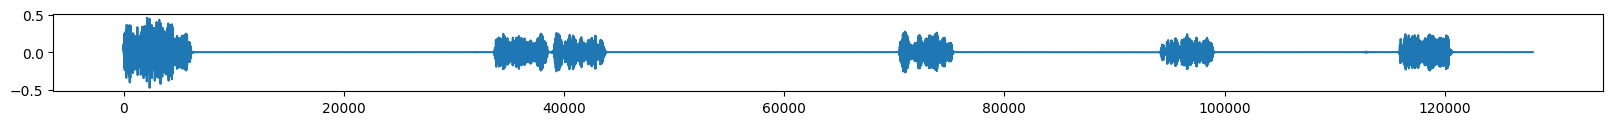

Finished epoch number 54 with a total of 10000 debug_seqs
 time: 2025-08-29 11:48:15.926952, epoch 55,  Loss: 0.0218
About to call inference with p_inp.shape = torch.Size([1, 100, 129]), x.shape = torch.Size([100, 128]), and c.shape = torch.Size([300, 1])
About to call inference with p_inp.device = cpu, x.device = cpu, and c.device = cpu
Starting latent inference... with codebook_size=1024, n_q=4, cond_size=1
Warming up model hidden state with provided latents...
Generating 300 latent frames...
Latent generation complete. RNN time to generate: 2.29. Converting to audio...
Inference complete - encoding time = 0.04.
plot the audio which has shape (128000,)


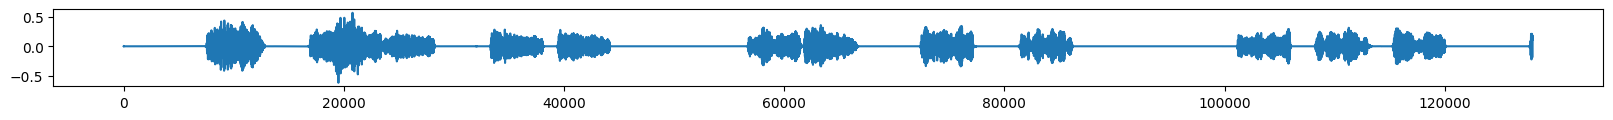

Finished epoch number 55 with a total of 10000 debug_seqs
 time: 2025-08-29 11:48:47.446619, epoch 56,  Loss: 0.0217
About to call inference with p_inp.shape = torch.Size([1, 100, 129]), x.shape = torch.Size([100, 128]), and c.shape = torch.Size([300, 1])
About to call inference with p_inp.device = cpu, x.device = cpu, and c.device = cpu
Starting latent inference... with codebook_size=1024, n_q=4, cond_size=1
Warming up model hidden state with provided latents...
Generating 300 latent frames...
Latent generation complete. RNN time to generate: 2.41. Converting to audio...
Inference complete - encoding time = 0.14.
plot the audio which has shape (128000,)


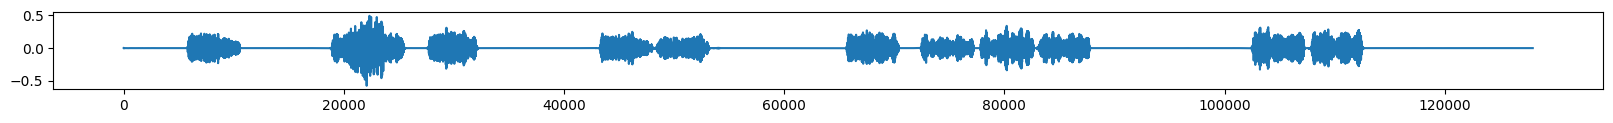

Finished epoch number 56 with a total of 10000 debug_seqs
 time: 2025-08-29 11:49:18.380952, epoch 57,  Loss: 0.0219
About to call inference with p_inp.shape = torch.Size([1, 100, 129]), x.shape = torch.Size([100, 128]), and c.shape = torch.Size([300, 1])
About to call inference with p_inp.device = cpu, x.device = cpu, and c.device = cpu
Starting latent inference... with codebook_size=1024, n_q=4, cond_size=1
Warming up model hidden state with provided latents...
Generating 300 latent frames...
Latent generation complete. RNN time to generate: 2.81. Converting to audio...
Inference complete - encoding time = 0.11.
plot the audio which has shape (128000,)


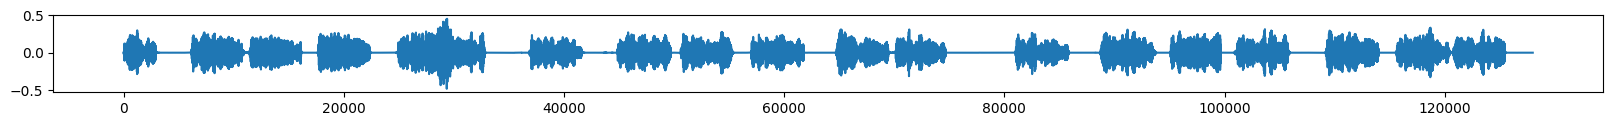

Finished epoch number 57 with a total of 10000 debug_seqs
 time: 2025-08-29 11:49:50.403479, epoch 58,  Loss: 0.0215
About to call inference with p_inp.shape = torch.Size([1, 100, 129]), x.shape = torch.Size([100, 128]), and c.shape = torch.Size([300, 1])
About to call inference with p_inp.device = cpu, x.device = cpu, and c.device = cpu
Starting latent inference... with codebook_size=1024, n_q=4, cond_size=1
Warming up model hidden state with provided latents...
Generating 300 latent frames...
Latent generation complete. RNN time to generate: 2.29. Converting to audio...
Inference complete - encoding time = 0.12.
plot the audio which has shape (128000,)


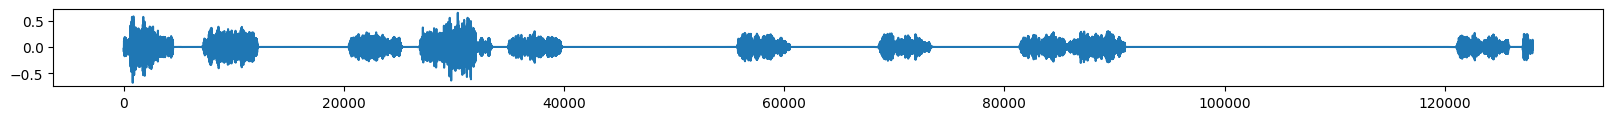

Finished epoch number 58 with a total of 10000 debug_seqs
 time: 2025-08-29 11:50:21.860142, epoch 59,  Loss: 0.0213
About to call inference with p_inp.shape = torch.Size([1, 100, 129]), x.shape = torch.Size([100, 128]), and c.shape = torch.Size([300, 1])
About to call inference with p_inp.device = cpu, x.device = cpu, and c.device = cpu
Starting latent inference... with codebook_size=1024, n_q=4, cond_size=1
Warming up model hidden state with provided latents...
Generating 300 latent frames...
Latent generation complete. RNN time to generate: 2.61. Converting to audio...
Inference complete - encoding time = 0.02.
plot the audio which has shape (128000,)


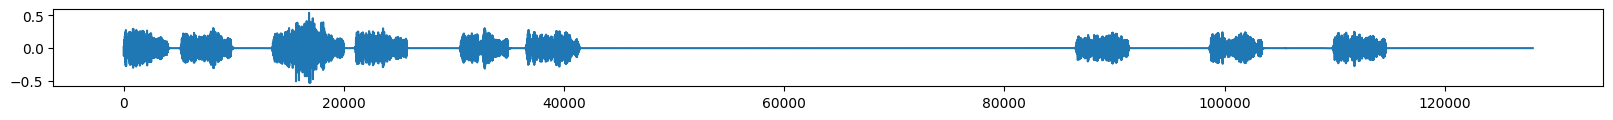

Finished epoch number 59 with a total of 10000 debug_seqs
 time: 2025-08-29 11:50:53.714925, epoch 60,  Loss: 0.0215
About to call inference with p_inp.shape = torch.Size([1, 100, 129]), x.shape = torch.Size([100, 128]), and c.shape = torch.Size([300, 1])
About to call inference with p_inp.device = cpu, x.device = cpu, and c.device = cpu
Starting latent inference... with codebook_size=1024, n_q=4, cond_size=1
Warming up model hidden state with provided latents...
Generating 300 latent frames...
Latent generation complete. RNN time to generate: 2.62. Converting to audio...
Inference complete - encoding time = 0.02.
plot the audio which has shape (128000,)


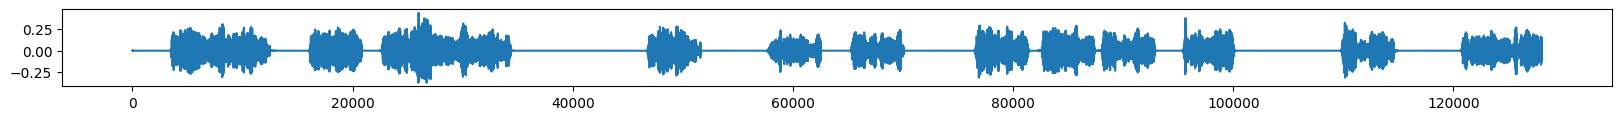

Saved checkpoint at epoch 60
Finished epoch number 60 with a total of 10000 debug_seqs
 time: 2025-08-29 11:51:25.509050, epoch 61,  Loss: 0.0219
About to call inference with p_inp.shape = torch.Size([1, 100, 129]), x.shape = torch.Size([100, 128]), and c.shape = torch.Size([300, 1])
About to call inference with p_inp.device = cpu, x.device = cpu, and c.device = cpu
Starting latent inference... with codebook_size=1024, n_q=4, cond_size=1
Warming up model hidden state with provided latents...
Generating 300 latent frames...
Latent generation complete. RNN time to generate: 2.57. Converting to audio...
Inference complete - encoding time = 0.02.
plot the audio which has shape (128000,)


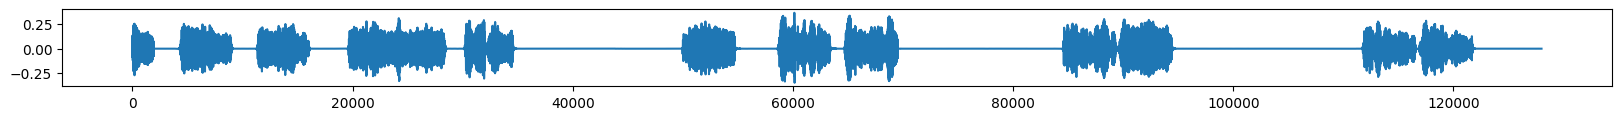

Finished epoch number 61 with a total of 10000 debug_seqs
 time: 2025-08-29 11:51:46.312700, epoch 62,  Loss: 0.0208
About to call inference with p_inp.shape = torch.Size([1, 100, 129]), x.shape = torch.Size([100, 128]), and c.shape = torch.Size([300, 1])
About to call inference with p_inp.device = cpu, x.device = cpu, and c.device = cpu
Starting latent inference... with codebook_size=1024, n_q=4, cond_size=1
Warming up model hidden state with provided latents...
Generating 300 latent frames...
Latent generation complete. RNN time to generate: 0.60. Converting to audio...
Inference complete - encoding time = 0.02.
plot the audio which has shape (128000,)


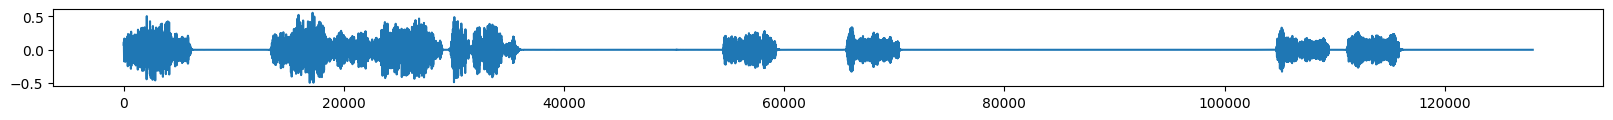

Finished epoch number 62 with a total of 10000 debug_seqs
 time: 2025-08-29 11:51:57.834153, epoch 63,  Loss: 0.0202
About to call inference with p_inp.shape = torch.Size([1, 100, 129]), x.shape = torch.Size([100, 128]), and c.shape = torch.Size([300, 1])
About to call inference with p_inp.device = cpu, x.device = cpu, and c.device = cpu
Starting latent inference... with codebook_size=1024, n_q=4, cond_size=1
Warming up model hidden state with provided latents...
Generating 300 latent frames...
Latent generation complete. RNN time to generate: 0.59. Converting to audio...
Inference complete - encoding time = 0.02.
plot the audio which has shape (128000,)


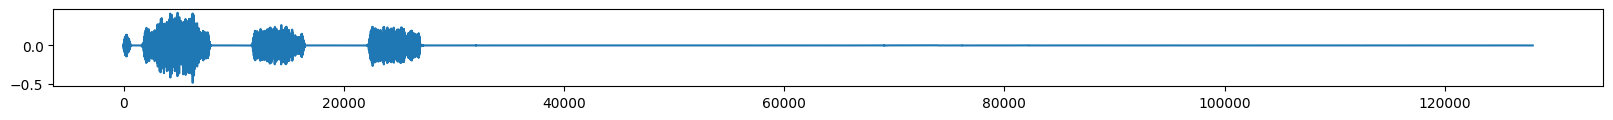

Finished epoch number 63 with a total of 10000 debug_seqs
 time: 2025-08-29 11:52:09.296356, epoch 64,  Loss: 0.0209
About to call inference with p_inp.shape = torch.Size([1, 100, 129]), x.shape = torch.Size([100, 128]), and c.shape = torch.Size([300, 1])
About to call inference with p_inp.device = cpu, x.device = cpu, and c.device = cpu
Starting latent inference... with codebook_size=1024, n_q=4, cond_size=1
Warming up model hidden state with provided latents...
Generating 300 latent frames...
Latent generation complete. RNN time to generate: 0.59. Converting to audio...
Inference complete - encoding time = 0.02.
plot the audio which has shape (128000,)


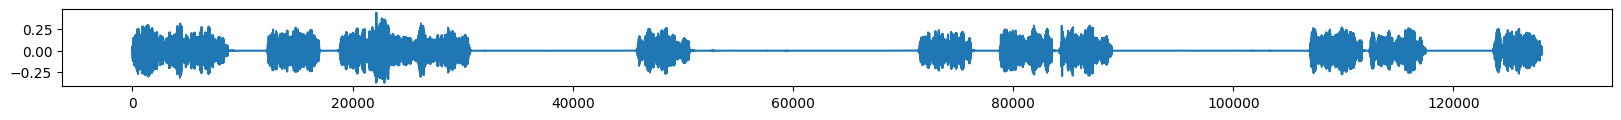

Finished epoch number 64 with a total of 10000 debug_seqs
 time: 2025-08-29 11:52:20.684218, epoch 65,  Loss: 0.0204
About to call inference with p_inp.shape = torch.Size([1, 100, 129]), x.shape = torch.Size([100, 128]), and c.shape = torch.Size([300, 1])
About to call inference with p_inp.device = cpu, x.device = cpu, and c.device = cpu
Starting latent inference... with codebook_size=1024, n_q=4, cond_size=1
Warming up model hidden state with provided latents...
Generating 300 latent frames...
Latent generation complete. RNN time to generate: 0.62. Converting to audio...
Inference complete - encoding time = 0.02.
plot the audio which has shape (128000,)


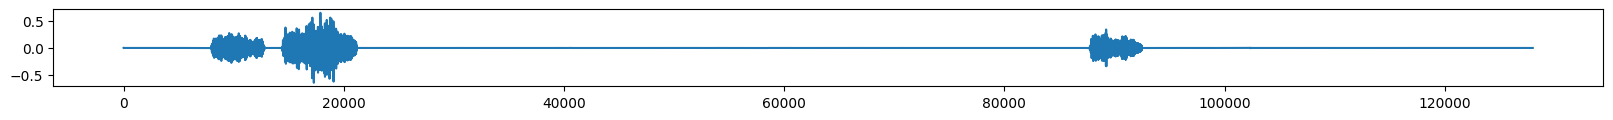

Finished epoch number 65 with a total of 10000 debug_seqs
 time: 2025-08-29 11:52:32.419892, epoch 66,  Loss: 0.0214
About to call inference with p_inp.shape = torch.Size([1, 100, 129]), x.shape = torch.Size([100, 128]), and c.shape = torch.Size([300, 1])
About to call inference with p_inp.device = cpu, x.device = cpu, and c.device = cpu
Starting latent inference... with codebook_size=1024, n_q=4, cond_size=1
Warming up model hidden state with provided latents...
Generating 300 latent frames...
Latent generation complete. RNN time to generate: 0.63. Converting to audio...
Inference complete - encoding time = 0.02.
plot the audio which has shape (128000,)


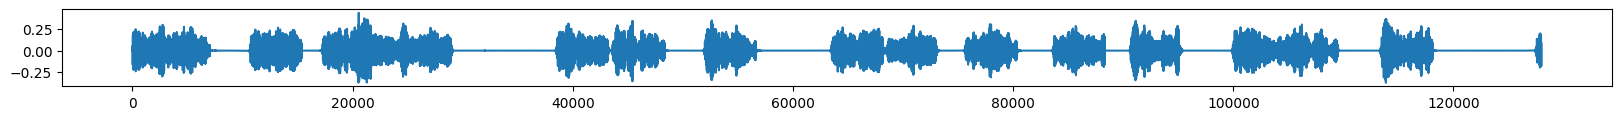

Finished epoch number 66 with a total of 10000 debug_seqs
 time: 2025-08-29 11:52:44.201571, epoch 67,  Loss: 0.0207
About to call inference with p_inp.shape = torch.Size([1, 100, 129]), x.shape = torch.Size([100, 128]), and c.shape = torch.Size([300, 1])
About to call inference with p_inp.device = cpu, x.device = cpu, and c.device = cpu
Starting latent inference... with codebook_size=1024, n_q=4, cond_size=1
Warming up model hidden state with provided latents...
Generating 300 latent frames...
Latent generation complete. RNN time to generate: 0.60. Converting to audio...
Inference complete - encoding time = 0.02.
plot the audio which has shape (128000,)


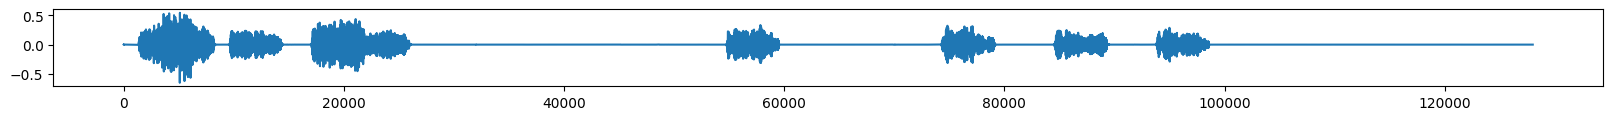

Finished epoch number 67 with a total of 10000 debug_seqs
 time: 2025-08-29 11:52:59.081673, epoch 68,  Loss: 0.0207
About to call inference with p_inp.shape = torch.Size([1, 100, 129]), x.shape = torch.Size([100, 128]), and c.shape = torch.Size([300, 1])
About to call inference with p_inp.device = cpu, x.device = cpu, and c.device = cpu
Starting latent inference... with codebook_size=1024, n_q=4, cond_size=1
Warming up model hidden state with provided latents...
Generating 300 latent frames...
Latent generation complete. RNN time to generate: 1.90. Converting to audio...
Inference complete - encoding time = 0.05.
plot the audio which has shape (128000,)


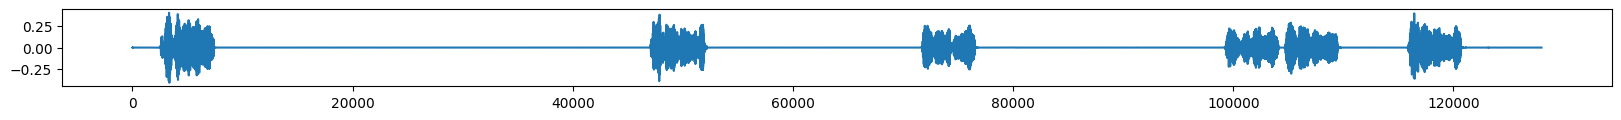

Finished epoch number 68 with a total of 10000 debug_seqs
 time: 2025-08-29 11:53:30.044256, epoch 69,  Loss: 0.0200
About to call inference with p_inp.shape = torch.Size([1, 100, 129]), x.shape = torch.Size([100, 128]), and c.shape = torch.Size([300, 1])
About to call inference with p_inp.device = cpu, x.device = cpu, and c.device = cpu
Starting latent inference... with codebook_size=1024, n_q=4, cond_size=1
Warming up model hidden state with provided latents...
Generating 300 latent frames...
Latent generation complete. RNN time to generate: 2.39. Converting to audio...
Inference complete - encoding time = 0.02.
plot the audio which has shape (128000,)


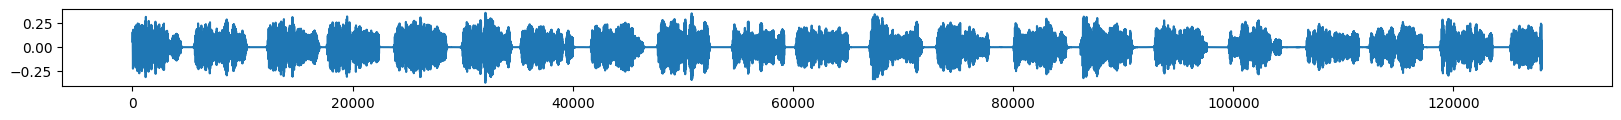

Finished epoch number 69 with a total of 10000 debug_seqs
 time: 2025-08-29 11:54:00.377309, epoch 70,  Loss: 0.0205
About to call inference with p_inp.shape = torch.Size([1, 100, 129]), x.shape = torch.Size([100, 128]), and c.shape = torch.Size([300, 1])
About to call inference with p_inp.device = cpu, x.device = cpu, and c.device = cpu
Starting latent inference... with codebook_size=1024, n_q=4, cond_size=1
Warming up model hidden state with provided latents...
Generating 300 latent frames...
Latent generation complete. RNN time to generate: 2.67. Converting to audio...
Inference complete - encoding time = 0.12.
plot the audio which has shape (128000,)


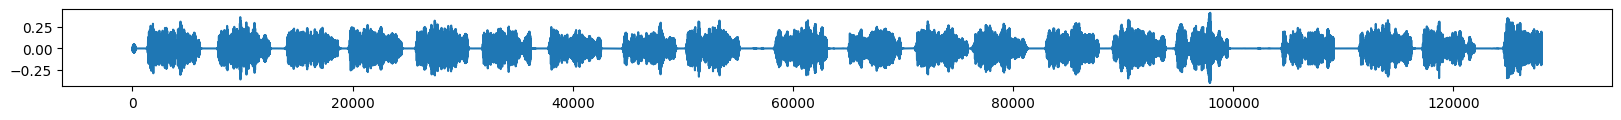

Saved checkpoint at epoch 70
Finished epoch number 70 with a total of 10000 debug_seqs
 time: 2025-08-29 11:54:31.394611, epoch 71,  Loss: 0.0207
About to call inference with p_inp.shape = torch.Size([1, 100, 129]), x.shape = torch.Size([100, 128]), and c.shape = torch.Size([300, 1])
About to call inference with p_inp.device = cpu, x.device = cpu, and c.device = cpu
Starting latent inference... with codebook_size=1024, n_q=4, cond_size=1
Warming up model hidden state with provided latents...
Generating 300 latent frames...
Latent generation complete. RNN time to generate: 2.19. Converting to audio...
Inference complete - encoding time = 0.12.
plot the audio which has shape (128000,)


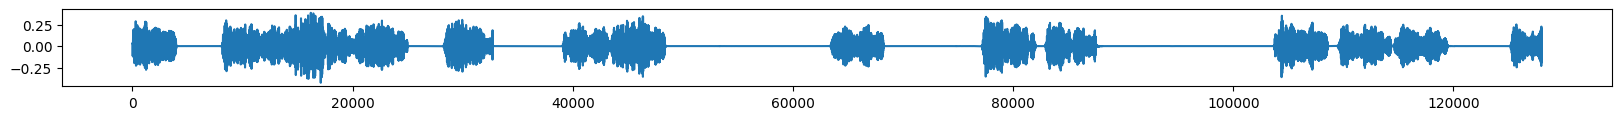

Finished epoch number 71 with a total of 10000 debug_seqs
 time: 2025-08-29 11:55:01.971622, epoch 72,  Loss: 0.0211
About to call inference with p_inp.shape = torch.Size([1, 100, 129]), x.shape = torch.Size([100, 128]), and c.shape = torch.Size([300, 1])
About to call inference with p_inp.device = cpu, x.device = cpu, and c.device = cpu
Starting latent inference... with codebook_size=1024, n_q=4, cond_size=1
Warming up model hidden state with provided latents...
Generating 300 latent frames...
Latent generation complete. RNN time to generate: 2.47. Converting to audio...
Inference complete - encoding time = 0.12.
plot the audio which has shape (128000,)


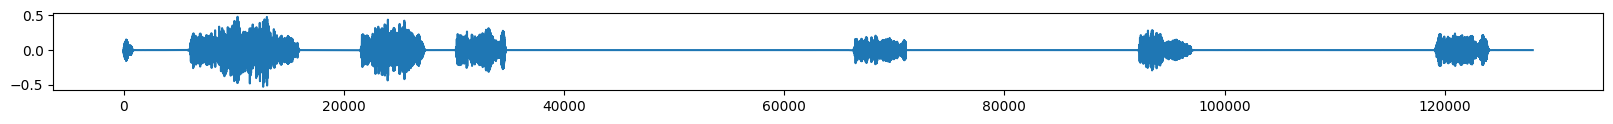

Finished epoch number 72 with a total of 10000 debug_seqs
 time: 2025-08-29 11:55:33.196929, epoch 73,  Loss: 0.0208
About to call inference with p_inp.shape = torch.Size([1, 100, 129]), x.shape = torch.Size([100, 128]), and c.shape = torch.Size([300, 1])
About to call inference with p_inp.device = cpu, x.device = cpu, and c.device = cpu
Starting latent inference... with codebook_size=1024, n_q=4, cond_size=1
Warming up model hidden state with provided latents...
Generating 300 latent frames...
Latent generation complete. RNN time to generate: 2.72. Converting to audio...
Inference complete - encoding time = 0.13.
plot the audio which has shape (128000,)


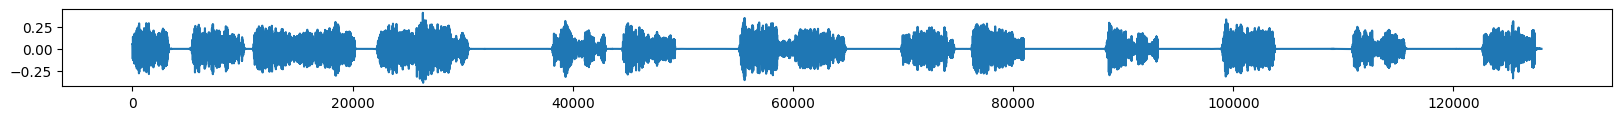

Finished epoch number 73 with a total of 10000 debug_seqs
 time: 2025-08-29 11:56:04.573339, epoch 74,  Loss: 0.0209
About to call inference with p_inp.shape = torch.Size([1, 100, 129]), x.shape = torch.Size([100, 128]), and c.shape = torch.Size([300, 1])
About to call inference with p_inp.device = cpu, x.device = cpu, and c.device = cpu
Starting latent inference... with codebook_size=1024, n_q=4, cond_size=1
Warming up model hidden state with provided latents...
Generating 300 latent frames...
Latent generation complete. RNN time to generate: 2.57. Converting to audio...
Inference complete - encoding time = 0.02.
plot the audio which has shape (128000,)


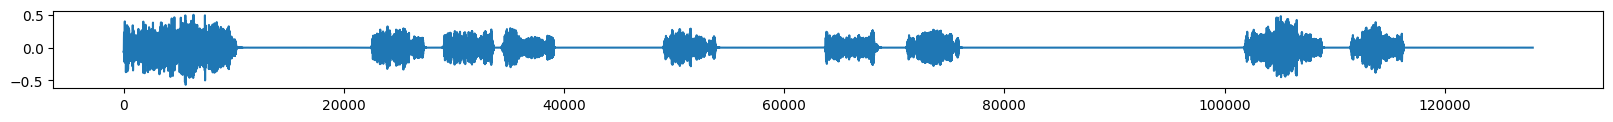

Finished epoch number 74 with a total of 10000 debug_seqs
 time: 2025-08-29 11:56:32.700523, epoch 75,  Loss: 0.0211
About to call inference with p_inp.shape = torch.Size([1, 100, 129]), x.shape = torch.Size([100, 128]), and c.shape = torch.Size([300, 1])
About to call inference with p_inp.device = cpu, x.device = cpu, and c.device = cpu
Starting latent inference... with codebook_size=1024, n_q=4, cond_size=1
Warming up model hidden state with provided latents...
Generating 300 latent frames...
Latent generation complete. RNN time to generate: 1.89. Converting to audio...
Inference complete - encoding time = 0.02.
plot the audio which has shape (128000,)


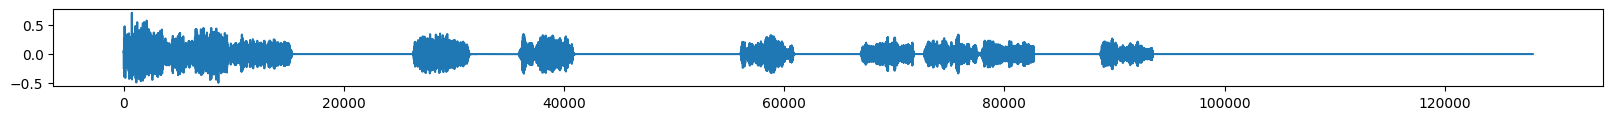

Finished epoch number 75 with a total of 10000 debug_seqs
 time: 2025-08-29 11:57:00.170573, epoch 76,  Loss: 0.0206
About to call inference with p_inp.shape = torch.Size([1, 100, 129]), x.shape = torch.Size([100, 128]), and c.shape = torch.Size([300, 1])
About to call inference with p_inp.device = cpu, x.device = cpu, and c.device = cpu
Starting latent inference... with codebook_size=1024, n_q=4, cond_size=1
Warming up model hidden state with provided latents...
Generating 300 latent frames...
Latent generation complete. RNN time to generate: 2.45. Converting to audio...
Inference complete - encoding time = 0.11.
plot the audio which has shape (128000,)


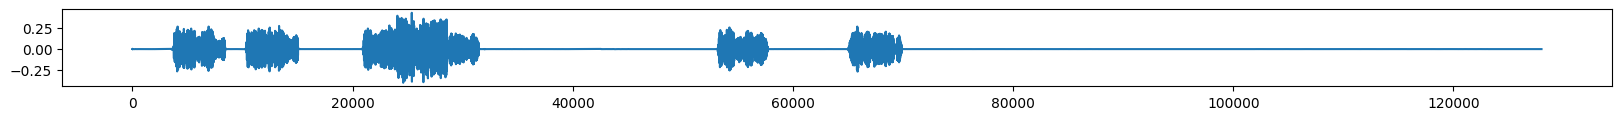

Finished epoch number 76 with a total of 10000 debug_seqs
 time: 2025-08-29 11:57:31.131012, epoch 77,  Loss: 0.0206
About to call inference with p_inp.shape = torch.Size([1, 100, 129]), x.shape = torch.Size([100, 128]), and c.shape = torch.Size([300, 1])
About to call inference with p_inp.device = cpu, x.device = cpu, and c.device = cpu
Starting latent inference... with codebook_size=1024, n_q=4, cond_size=1
Warming up model hidden state with provided latents...
Generating 300 latent frames...
Latent generation complete. RNN time to generate: 2.65. Converting to audio...
Inference complete - encoding time = 0.16.
plot the audio which has shape (128000,)


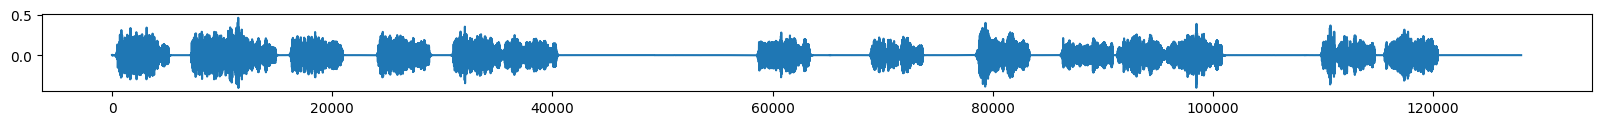

Finished epoch number 77 with a total of 10000 debug_seqs
 time: 2025-08-29 11:58:02.356592, epoch 78,  Loss: 0.0202
About to call inference with p_inp.shape = torch.Size([1, 100, 129]), x.shape = torch.Size([100, 128]), and c.shape = torch.Size([300, 1])
About to call inference with p_inp.device = cpu, x.device = cpu, and c.device = cpu
Starting latent inference... with codebook_size=1024, n_q=4, cond_size=1
Warming up model hidden state with provided latents...
Generating 300 latent frames...
Latent generation complete. RNN time to generate: 2.53. Converting to audio...
Inference complete - encoding time = 0.14.
plot the audio which has shape (128000,)


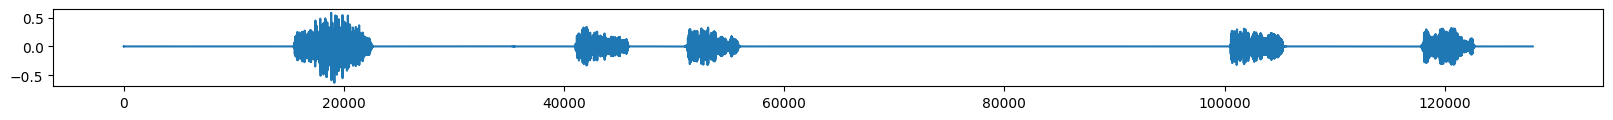

Finished epoch number 78 with a total of 10000 debug_seqs
 time: 2025-08-29 11:58:33.517242, epoch 79,  Loss: 0.0208
About to call inference with p_inp.shape = torch.Size([1, 100, 129]), x.shape = torch.Size([100, 128]), and c.shape = torch.Size([300, 1])
About to call inference with p_inp.device = cpu, x.device = cpu, and c.device = cpu
Starting latent inference... with codebook_size=1024, n_q=4, cond_size=1
Warming up model hidden state with provided latents...
Generating 300 latent frames...
Latent generation complete. RNN time to generate: 2.82. Converting to audio...
Inference complete - encoding time = 0.04.
plot the audio which has shape (128000,)


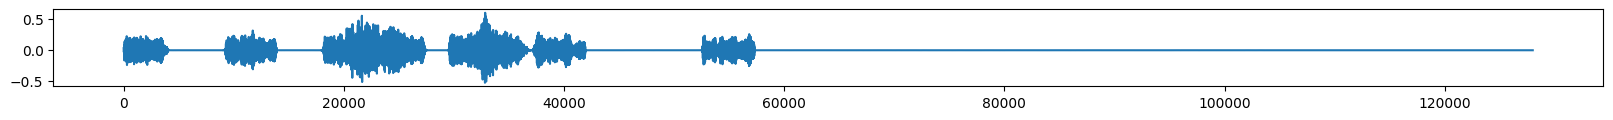

Finished epoch number 79 with a total of 10000 debug_seqs
 time: 2025-08-29 11:59:04.618469, epoch 80,  Loss: 0.0204
About to call inference with p_inp.shape = torch.Size([1, 100, 129]), x.shape = torch.Size([100, 128]), and c.shape = torch.Size([300, 1])
About to call inference with p_inp.device = cpu, x.device = cpu, and c.device = cpu
Starting latent inference... with codebook_size=1024, n_q=4, cond_size=1
Warming up model hidden state with provided latents...
Generating 300 latent frames...
Latent generation complete. RNN time to generate: 2.39. Converting to audio...
Inference complete - encoding time = 0.16.
plot the audio which has shape (128000,)


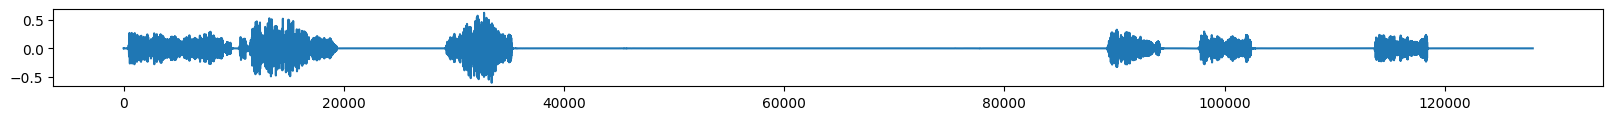

Saved checkpoint at epoch 80
Finished epoch number 80 with a total of 10000 debug_seqs
 time: 2025-08-29 11:59:35.324639, epoch 81,  Loss: 0.0209
About to call inference with p_inp.shape = torch.Size([1, 100, 129]), x.shape = torch.Size([100, 128]), and c.shape = torch.Size([300, 1])
About to call inference with p_inp.device = cpu, x.device = cpu, and c.device = cpu
Starting latent inference... with codebook_size=1024, n_q=4, cond_size=1
Warming up model hidden state with provided latents...
Generating 300 latent frames...
Latent generation complete. RNN time to generate: 2.75. Converting to audio...
Inference complete - encoding time = 0.10.
plot the audio which has shape (128000,)


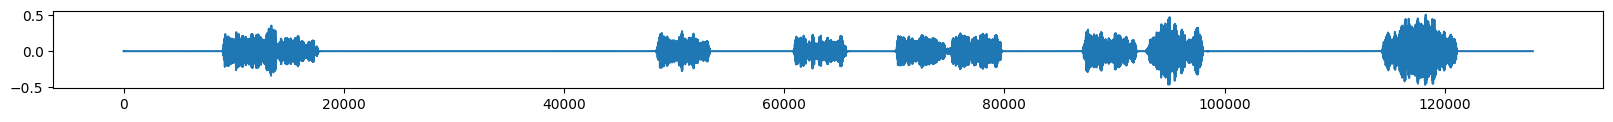

Finished epoch number 81 with a total of 10000 debug_seqs
 time: 2025-08-29 12:00:07.085155, epoch 82,  Loss: 0.0206
About to call inference with p_inp.shape = torch.Size([1, 100, 129]), x.shape = torch.Size([100, 128]), and c.shape = torch.Size([300, 1])
About to call inference with p_inp.device = cpu, x.device = cpu, and c.device = cpu
Starting latent inference... with codebook_size=1024, n_q=4, cond_size=1
Warming up model hidden state with provided latents...
Generating 300 latent frames...
Latent generation complete. RNN time to generate: 2.66. Converting to audio...
Inference complete - encoding time = 0.10.
plot the audio which has shape (128000,)


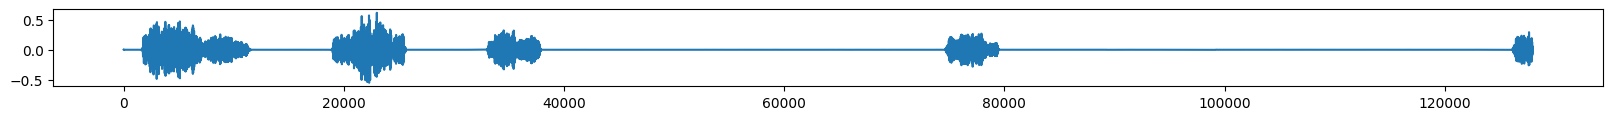

Finished epoch number 82 with a total of 10000 debug_seqs
 time: 2025-08-29 12:00:39.541901, epoch 83,  Loss: 0.0197
About to call inference with p_inp.shape = torch.Size([1, 100, 129]), x.shape = torch.Size([100, 128]), and c.shape = torch.Size([300, 1])
About to call inference with p_inp.device = cpu, x.device = cpu, and c.device = cpu
Starting latent inference... with codebook_size=1024, n_q=4, cond_size=1
Warming up model hidden state with provided latents...
Generating 300 latent frames...
Latent generation complete. RNN time to generate: 2.51. Converting to audio...
Inference complete - encoding time = 0.02.
plot the audio which has shape (128000,)


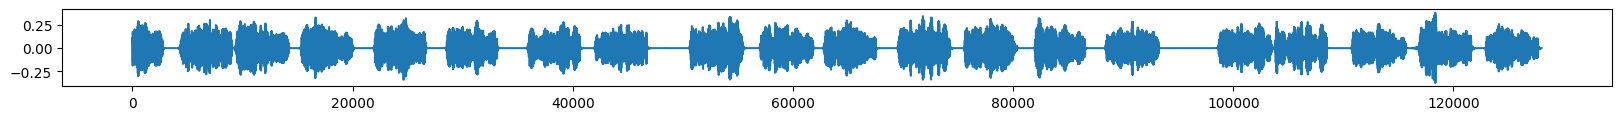

Finished epoch number 83 with a total of 10000 debug_seqs
 time: 2025-08-29 12:01:10.229374, epoch 84,  Loss: 0.0200
About to call inference with p_inp.shape = torch.Size([1, 100, 129]), x.shape = torch.Size([100, 128]), and c.shape = torch.Size([300, 1])
About to call inference with p_inp.device = cpu, x.device = cpu, and c.device = cpu
Starting latent inference... with codebook_size=1024, n_q=4, cond_size=1
Warming up model hidden state with provided latents...
Generating 300 latent frames...
Latent generation complete. RNN time to generate: 2.73. Converting to audio...
Inference complete - encoding time = 0.16.
plot the audio which has shape (128000,)


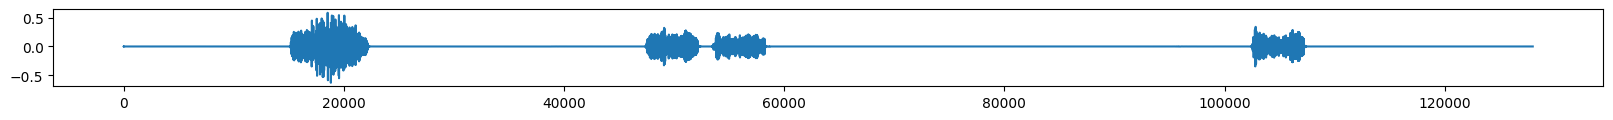

Finished epoch number 84 with a total of 10000 debug_seqs
 time: 2025-08-29 12:01:41.650959, epoch 85,  Loss: 0.0205
About to call inference with p_inp.shape = torch.Size([1, 100, 129]), x.shape = torch.Size([100, 128]), and c.shape = torch.Size([300, 1])
About to call inference with p_inp.device = cpu, x.device = cpu, and c.device = cpu
Starting latent inference... with codebook_size=1024, n_q=4, cond_size=1
Warming up model hidden state with provided latents...
Generating 300 latent frames...
Latent generation complete. RNN time to generate: 2.53. Converting to audio...
Inference complete - encoding time = 0.02.
plot the audio which has shape (128000,)


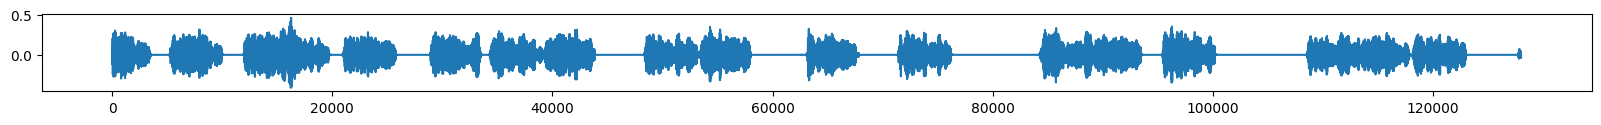

Finished epoch number 85 with a total of 10000 debug_seqs
 time: 2025-08-29 12:02:12.962591, epoch 86,  Loss: 0.0206
About to call inference with p_inp.shape = torch.Size([1, 100, 129]), x.shape = torch.Size([100, 128]), and c.shape = torch.Size([300, 1])
About to call inference with p_inp.device = cpu, x.device = cpu, and c.device = cpu
Starting latent inference... with codebook_size=1024, n_q=4, cond_size=1
Warming up model hidden state with provided latents...
Generating 300 latent frames...
Latent generation complete. RNN time to generate: 2.53. Converting to audio...
Inference complete - encoding time = 0.13.
plot the audio which has shape (128000,)


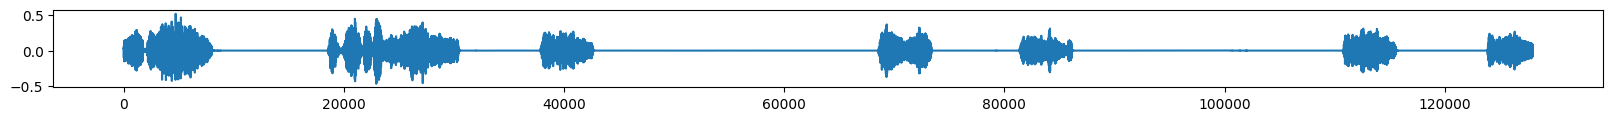

Finished epoch number 86 with a total of 10000 debug_seqs
 time: 2025-08-29 12:02:45.249590, epoch 87,  Loss: 0.0205
About to call inference with p_inp.shape = torch.Size([1, 100, 129]), x.shape = torch.Size([100, 128]), and c.shape = torch.Size([300, 1])
About to call inference with p_inp.device = cpu, x.device = cpu, and c.device = cpu
Starting latent inference... with codebook_size=1024, n_q=4, cond_size=1
Warming up model hidden state with provided latents...
Generating 300 latent frames...
Latent generation complete. RNN time to generate: 2.50. Converting to audio...
Inference complete - encoding time = 0.16.
plot the audio which has shape (128000,)


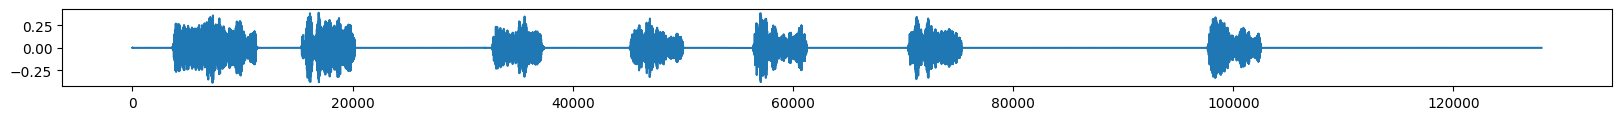

Finished epoch number 87 with a total of 10000 debug_seqs
 time: 2025-08-29 12:03:17.215959, epoch 88,  Loss: 0.0200
About to call inference with p_inp.shape = torch.Size([1, 100, 129]), x.shape = torch.Size([100, 128]), and c.shape = torch.Size([300, 1])
About to call inference with p_inp.device = cpu, x.device = cpu, and c.device = cpu
Starting latent inference... with codebook_size=1024, n_q=4, cond_size=1
Warming up model hidden state with provided latents...
Generating 300 latent frames...
Latent generation complete. RNN time to generate: 2.47. Converting to audio...
Inference complete - encoding time = 0.02.
plot the audio which has shape (128000,)


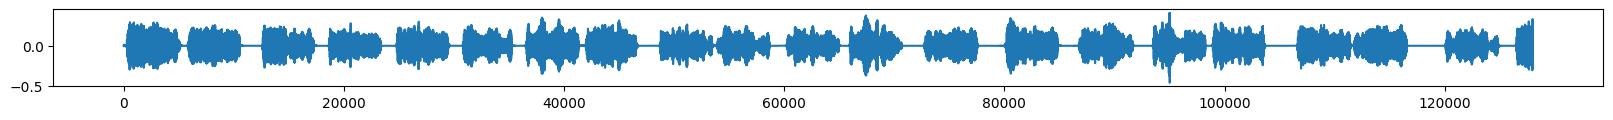

Finished epoch number 88 with a total of 10000 debug_seqs
 time: 2025-08-29 12:03:46.475498, epoch 89,  Loss: 0.0208
About to call inference with p_inp.shape = torch.Size([1, 100, 129]), x.shape = torch.Size([100, 128]), and c.shape = torch.Size([300, 1])
About to call inference with p_inp.device = cpu, x.device = cpu, and c.device = cpu
Starting latent inference... with codebook_size=1024, n_q=4, cond_size=1
Warming up model hidden state with provided latents...
Generating 300 latent frames...
Latent generation complete. RNN time to generate: 1.68. Converting to audio...
Inference complete - encoding time = 0.13.
plot the audio which has shape (128000,)


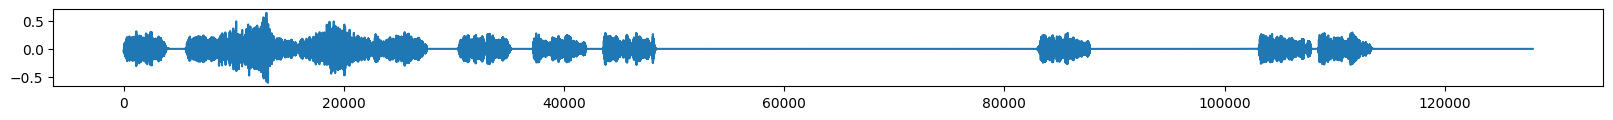

Finished epoch number 89 with a total of 10000 debug_seqs
 time: 2025-08-29 12:04:12.438012, epoch 90,  Loss: 0.0215
About to call inference with p_inp.shape = torch.Size([1, 100, 129]), x.shape = torch.Size([100, 128]), and c.shape = torch.Size([300, 1])
About to call inference with p_inp.device = cpu, x.device = cpu, and c.device = cpu
Starting latent inference... with codebook_size=1024, n_q=4, cond_size=1
Warming up model hidden state with provided latents...
Generating 300 latent frames...
Latent generation complete. RNN time to generate: 2.00. Converting to audio...
Inference complete - encoding time = 0.14.
plot the audio which has shape (128000,)


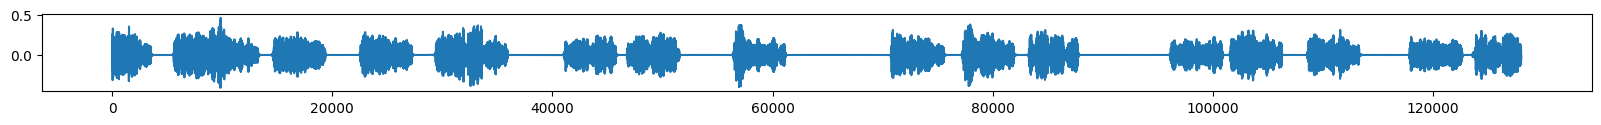

Saved checkpoint at epoch 90
Finished epoch number 90 with a total of 10000 debug_seqs
 time: 2025-08-29 12:04:43.679179, epoch 91,  Loss: 0.0206
About to call inference with p_inp.shape = torch.Size([1, 100, 129]), x.shape = torch.Size([100, 128]), and c.shape = torch.Size([300, 1])
About to call inference with p_inp.device = cpu, x.device = cpu, and c.device = cpu
Starting latent inference... with codebook_size=1024, n_q=4, cond_size=1
Warming up model hidden state with provided latents...
Generating 300 latent frames...
Latent generation complete. RNN time to generate: 2.28. Converting to audio...
Inference complete - encoding time = 0.14.
plot the audio which has shape (128000,)


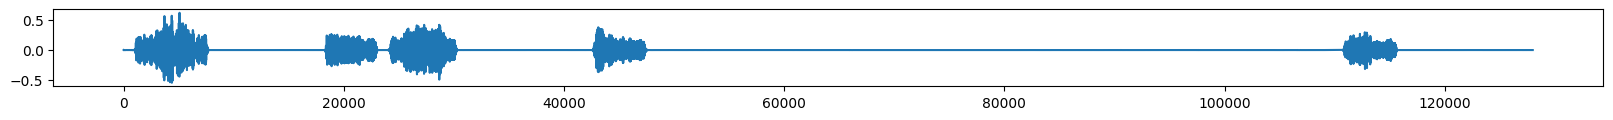

Finished epoch number 91 with a total of 10000 debug_seqs
 time: 2025-08-29 12:05:14.975840, epoch 92,  Loss: 0.0202
About to call inference with p_inp.shape = torch.Size([1, 100, 129]), x.shape = torch.Size([100, 128]), and c.shape = torch.Size([300, 1])
About to call inference with p_inp.device = cpu, x.device = cpu, and c.device = cpu
Starting latent inference... with codebook_size=1024, n_q=4, cond_size=1
Warming up model hidden state with provided latents...
Generating 300 latent frames...
Latent generation complete. RNN time to generate: 2.56. Converting to audio...
Inference complete - encoding time = 0.13.
plot the audio which has shape (128000,)


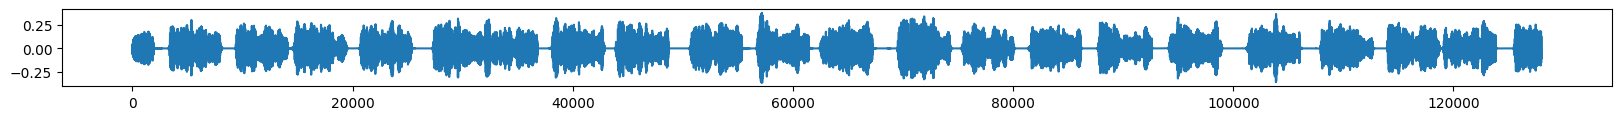

Finished epoch number 92 with a total of 10000 debug_seqs
 time: 2025-08-29 12:05:46.669249, epoch 93,  Loss: 0.0209
About to call inference with p_inp.shape = torch.Size([1, 100, 129]), x.shape = torch.Size([100, 128]), and c.shape = torch.Size([300, 1])
About to call inference with p_inp.device = cpu, x.device = cpu, and c.device = cpu
Starting latent inference... with codebook_size=1024, n_q=4, cond_size=1
Warming up model hidden state with provided latents...
Generating 300 latent frames...
Latent generation complete. RNN time to generate: 2.45. Converting to audio...
Inference complete - encoding time = 0.02.
plot the audio which has shape (128000,)


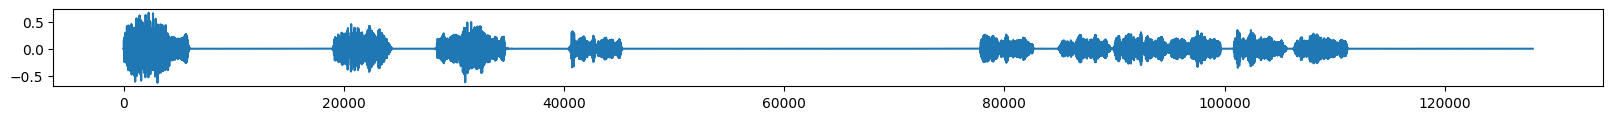

Finished epoch number 93 with a total of 10000 debug_seqs
 time: 2025-08-29 12:06:17.880611, epoch 94,  Loss: 0.0203
About to call inference with p_inp.shape = torch.Size([1, 100, 129]), x.shape = torch.Size([100, 128]), and c.shape = torch.Size([300, 1])
About to call inference with p_inp.device = cpu, x.device = cpu, and c.device = cpu
Starting latent inference... with codebook_size=1024, n_q=4, cond_size=1
Warming up model hidden state with provided latents...
Generating 300 latent frames...
Latent generation complete. RNN time to generate: 2.82. Converting to audio...
Inference complete - encoding time = 0.02.
plot the audio which has shape (128000,)


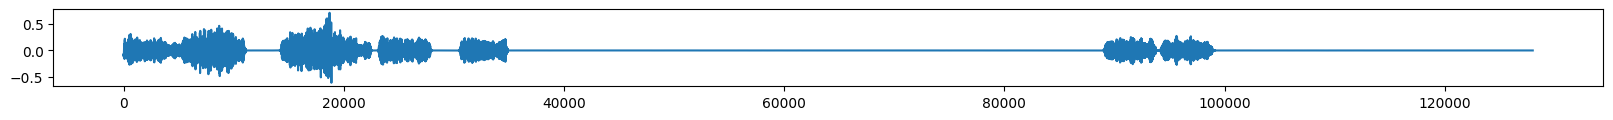

Finished epoch number 94 with a total of 10000 debug_seqs
 time: 2025-08-29 12:06:48.990756, epoch 95,  Loss: 0.0203
About to call inference with p_inp.shape = torch.Size([1, 100, 129]), x.shape = torch.Size([100, 128]), and c.shape = torch.Size([300, 1])
About to call inference with p_inp.device = cpu, x.device = cpu, and c.device = cpu
Starting latent inference... with codebook_size=1024, n_q=4, cond_size=1
Warming up model hidden state with provided latents...
Generating 300 latent frames...
Latent generation complete. RNN time to generate: 2.11. Converting to audio...
Inference complete - encoding time = 0.14.
plot the audio which has shape (128000,)


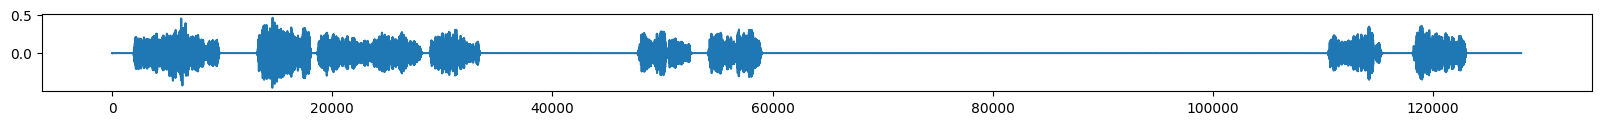

Finished epoch number 95 with a total of 10000 debug_seqs
 time: 2025-08-29 12:07:20.263665, epoch 96,  Loss: 0.0202
About to call inference with p_inp.shape = torch.Size([1, 100, 129]), x.shape = torch.Size([100, 128]), and c.shape = torch.Size([300, 1])
About to call inference with p_inp.device = cpu, x.device = cpu, and c.device = cpu
Starting latent inference... with codebook_size=1024, n_q=4, cond_size=1
Warming up model hidden state with provided latents...
Generating 300 latent frames...
Latent generation complete. RNN time to generate: 2.25. Converting to audio...
Inference complete - encoding time = 0.15.
plot the audio which has shape (128000,)


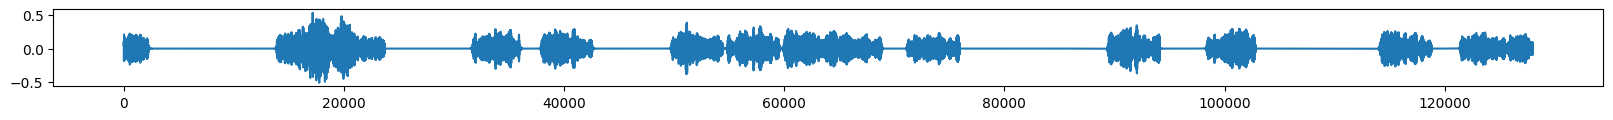

Finished epoch number 96 with a total of 10000 debug_seqs
 time: 2025-08-29 12:07:51.735394, epoch 97,  Loss: 0.0199
About to call inference with p_inp.shape = torch.Size([1, 100, 129]), x.shape = torch.Size([100, 128]), and c.shape = torch.Size([300, 1])
About to call inference with p_inp.device = cpu, x.device = cpu, and c.device = cpu
Starting latent inference... with codebook_size=1024, n_q=4, cond_size=1
Warming up model hidden state with provided latents...
Generating 300 latent frames...
Latent generation complete. RNN time to generate: 2.88. Converting to audio...
Inference complete - encoding time = 0.02.
plot the audio which has shape (128000,)


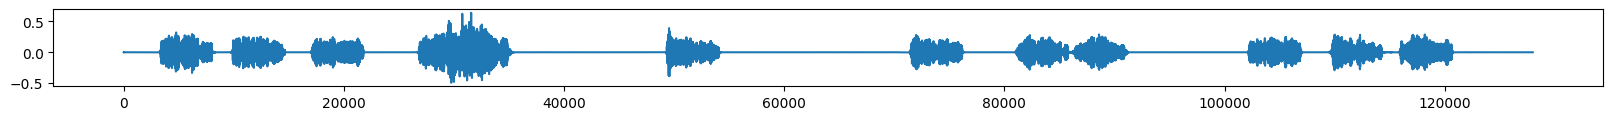

Finished epoch number 97 with a total of 10000 debug_seqs
 time: 2025-08-29 12:08:24.250485, epoch 98,  Loss: 0.0202
About to call inference with p_inp.shape = torch.Size([1, 100, 129]), x.shape = torch.Size([100, 128]), and c.shape = torch.Size([300, 1])
About to call inference with p_inp.device = cpu, x.device = cpu, and c.device = cpu
Starting latent inference... with codebook_size=1024, n_q=4, cond_size=1
Warming up model hidden state with provided latents...
Generating 300 latent frames...
Latent generation complete. RNN time to generate: 2.69. Converting to audio...
Inference complete - encoding time = 0.12.
plot the audio which has shape (128000,)


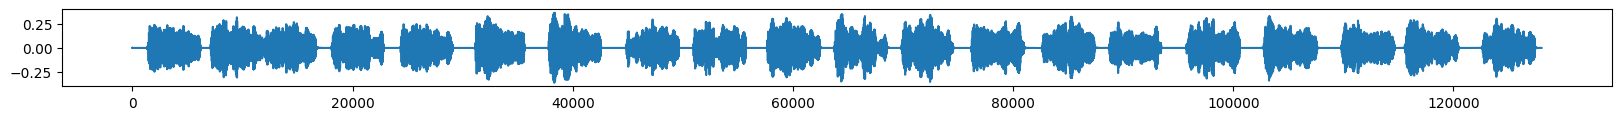

Finished epoch number 98 with a total of 10000 debug_seqs
 time: 2025-08-29 12:08:55.165592, epoch 99,  Loss: 0.0201
About to call inference with p_inp.shape = torch.Size([1, 100, 129]), x.shape = torch.Size([100, 128]), and c.shape = torch.Size([300, 1])
About to call inference with p_inp.device = cpu, x.device = cpu, and c.device = cpu
Starting latent inference... with codebook_size=1024, n_q=4, cond_size=1
Warming up model hidden state with provided latents...
Generating 300 latent frames...
Latent generation complete. RNN time to generate: 2.54. Converting to audio...
Inference complete - encoding time = 0.12.
plot the audio which has shape (128000,)


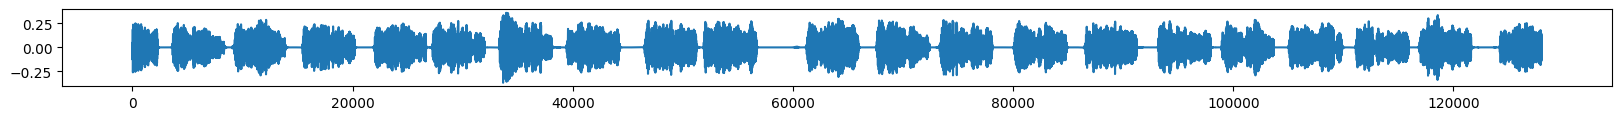

Finished epoch number 99 with a total of 10000 debug_seqs
 time: 2025-08-29 12:09:27.509895, epoch 100,  Loss: 0.0201
About to call inference with p_inp.shape = torch.Size([1, 100, 129]), x.shape = torch.Size([100, 128]), and c.shape = torch.Size([300, 1])
About to call inference with p_inp.device = cpu, x.device = cpu, and c.device = cpu
Starting latent inference... with codebook_size=1024, n_q=4, cond_size=1
Warming up model hidden state with provided latents...
Generating 300 latent frames...
Latent generation complete. RNN time to generate: 2.60. Converting to audio...
Inference complete - encoding time = 0.02.
plot the audio which has shape (128000,)


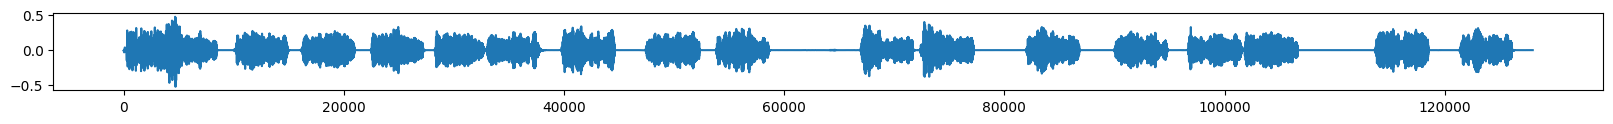

Saved checkpoint at epoch 100
Training time taken: 0:35:06
Saved checkpoint at epoch 100


'/home/lonce/working/RNN4Codecs/output/20250829_113424_encodectest_ChirpPattern/checkpoints/last_checkpoint.pt'

In [14]:
# Train!
#*************************************
enc_model.to(device)
list_of_losses = []

print('{:%Y-%m-%d %H:%M:%S} Starting training...'.format(datetime.now()))
start_time = time.monotonic()
#-------------------------------------------------------------------------------
for epoch in range(start_epoch, start_epoch+params['num_epochs']):
    train(rnn,epoch)
#-------------------------------------------------------------------------------
writer.close()
elapsed_time = time.monotonic() - start_time
print('Training time taken:',time_taken(elapsed_time))

#Just make sure the final model gets saved
checkpoint_data = {
    'epoch': epoch+1,
    'model_state_dict': rnn.state_dict(),
    'optimizer_state_dict': optimizer.state_dict()
}
# Save numbered checkpoint
numbered_path = os.path.join(f"{out_dir}/checkpoints", f"checkpoint_{epoch+1}.pt")
torch.save(checkpoint_data, numbered_path)
print(f"Saved checkpoint at epoch {epoch+1}")
# Copy to "last" (much faster than saving twice)
last_path = os.path.join(f"{out_dir}/checkpoints", "last_checkpoint.pt")
shutil.copy2(numbered_path, last_path)


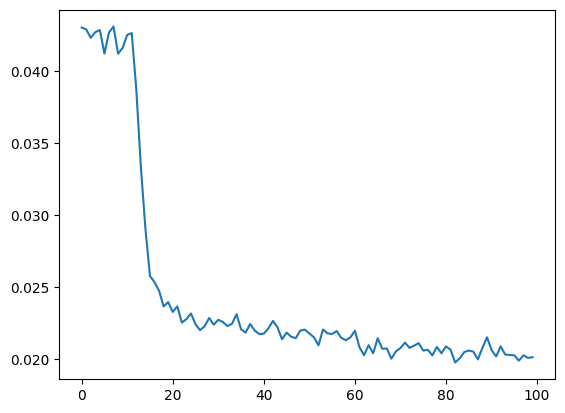

In [15]:
# Plot the loss over time
#*************************************
plt.figure()
plt.plot(list_of_losses)
plt.show()  # This will actually display the plot

In [16]:
list_of_losses

[0.04304808139801025,
 0.042923998832702634,
 0.04233454704284668,
 0.04272836685180664,
 0.042873930931091306,
 0.04123857498168945,
 0.04270263671875,
 0.04312379360198974,
 0.04122766971588135,
 0.04162982940673828,
 0.04253354549407959,
 0.04266043663024902,
 0.03874352216720581,
 0.0333642053604126,
 0.029058094024658202,
 0.025765292644500733,
 0.025326664447784423,
 0.02473133325576782,
 0.023640358448028566,
 0.023940141201019286,
 0.023258109092712403,
 0.023645145893096922,
 0.02251912832260132,
 0.022758569717407227,
 0.02315183639526367,
 0.022399225234985352,
 0.02199125528335571,
 0.0222601318359375,
 0.02284111261367798,
 0.022371668815612793,
 0.022709226608276366,
 0.02256284236907959,
 0.022277219295501707,
 0.02242642641067505,
 0.02309659719467163,
 0.022050695419311525,
 0.02181649684906006,
 0.02241800308227539,
 0.021963210105895997,
 0.02171135902404785,
 0.021753268241882326,
 0.02211363077163696,
 0.022633264064788817,
 0.022189040184020997,
 0.021355040073394